In [0]:
# Import PySpark functions for data transformation
from pyspark.sql import functions as F

# Import PySpark data types for defining schemas
from pyspark.sql import types as T

# Import Window for window based calculations
from pyspark.sql.window import Window

# Import Row for manually creating small Spark DataFrames
from pyspark.sql import Row

# Import standard Python libraries for file handling, text cleaning, timing, and downloads
import os
import re
import time
import zipfile
import requests

# Import typing helpers for cleaner function definitions
from typing import List, Dict

# Import data analysis and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [0]:
# Set the Unity Catalog name for the project
CATALOG = "new"

# Create Databricks widgets so values can be changed from the notebook UI
try:
    dbutils.widgets.text("schema", "airgreenops")
    dbutils.widgets.text("volume", "project_data")
    dbutils.widgets.text("years", "2023,2024,2025")
    dbutils.widgets.text("months", "1-12")
except Exception:
    pass


# Read a widget value and fall back to a default if the widget is missing or empty
def widget_value(name: str, default: str) -> str:
    try:
        value = dbutils.widgets.get(name)
        return value if value else default
    except Exception:
        return default


# Read configurable project values from widgets
SCHEMA = widget_value("schema", "airgreenops")
VOLUME = widget_value("volume", "project_data")
YEARS_TEXT = widget_value("years", "2023,2024,2025")
MONTHS_TEXT = widget_value("months", "1-12")

# Define the main project folders inside the Unity Catalog Volume
ROOT = f"/Volumes/{CATALOG}/{SCHEMA}/{VOLUME}/airgreenops"
RAW_BTS = f"{ROOT}/raw/bts"
RAW_NOAA = f"{ROOT}/raw/noaa"
RAW_AIRPORTS = f"{ROOT}/raw/airports"
MODEL_ROOT = f"{ROOT}/models"

# Define constants used later in the emissions calculation
CO2_FACTOR = 3.16
DEFAULT_FUEL_BURN_KG_PER_MIN = 12.0


# Safely wrap catalog, schema, and table names with backticks
def qident(name: str) -> str:
    return f"`{name.replace('`', '')}`"


# Build a fully qualified table name
def table_name(name: str) -> str:
    return f"{qident(CATALOG)}.{qident(SCHEMA)}.{qident(name)}"


# Ensure the project writes only to Databricks Volumes
def require_volume_path(path: str) -> None:
    if not path.startswith("/Volumes/"):
        raise ValueError(f"This project only writes to Databricks Volumes: {path}")


# Apply Spark settings when supported by the current cluster
for key, value in {
    "spark.sql.adaptive.enabled": "true",
    "spark.sql.shuffle.partitions": "200"
}.items():
    try:
        spark.conf.set(key, value)
    except Exception:
        pass


# Prepare the catalog, schema, and volume used by the project
spark.sql(f"USE CATALOG {qident(CATALOG)}")
spark.sql(f"CREATE SCHEMA IF NOT EXISTS {qident(SCHEMA)}")
spark.sql(f"USE SCHEMA {qident(SCHEMA)}")
spark.sql(f"CREATE VOLUME IF NOT EXISTS {qident(VOLUME)}")


# Create all required project folders
for path in [ROOT, RAW_BTS, RAW_NOAA, RAW_AIRPORTS, MODEL_ROOT]:
    require_volume_path(path)
    dbutils.fs.mkdirs(path)


# Print the final configuration for verification
print("Configuration ready")
print(f"Catalog: {CATALOG}")
print(f"Schema: {SCHEMA}")
print(f"Volume: {VOLUME}")
print(f"Project root: {ROOT}")
print(f"BTS raw path: {RAW_BTS}")
print(f"NOAA raw path: {RAW_NOAA}")
print(f"Airports raw path: {RAW_AIRPORTS}")
print(f"Models path: {MODEL_ROOT}")
print(f"CO2 factor: {CO2_FACTOR}")
print(f"Default fuel burn kg/min: {DEFAULT_FUEL_BURN_KG_PER_MIN}")

Configuration ready
Catalog: new
Schema: airgreenops
Volume: project_data
Project root: /Volumes/new/airgreenops/project_data/airgreenops
BTS raw path: /Volumes/new/airgreenops/project_data/airgreenops/raw/bts
NOAA raw path: /Volumes/new/airgreenops/project_data/airgreenops/raw/noaa
Airports raw path: /Volumes/new/airgreenops/project_data/airgreenops/raw/airports
Models path: /Volumes/new/airgreenops/project_data/airgreenops/models
CO2 factor: 3.16
Default fuel burn kg/min: 12.0


In [0]:
%sh

# Define the main project folder inside the Databricks Volume
ROOT="/Volumes/new/airgreenops/project_data/airgreenops"

# Define the raw folder where BTS flight data will be stored
RAW_BTS="$ROOT/raw/bts"

# Create the BTS raw folder if it does not already exist
mkdir -p "$RAW_BTS"

# Move into the BTS raw folder before downloading files
cd "$RAW_BTS"

# Download BTS monthly flight data for each selected year and month
for YEAR in 2023 2024 2025
do
  for MONTH in 1 2 3 4 5 6 7 8 9 10 11 12
  do
    # Build the BTS zip file name for the selected year and month
    ZIP_FILE="On_Time_Reporting_Carrier_On_Time_Performance_1987_present_${YEAR}_${MONTH}.zip"

    # Build the official BTS download URL
    URL="https://transtats.bts.gov/PREZIP/${ZIP_FILE}"

    # Download the monthly BTS zip file
    echo "Downloading $YEAR-$MONTH"
    curl -L -o "$ZIP_FILE" "$URL"

    # Extract the CSV file and remove the zip file to save space
    unzip -o "$ZIP_FILE"
    rm "$ZIP_FILE"
  done
done

# Show a sample of the downloaded BTS files
echo "BTS CSV files:"
ls -lh "$RAW_BTS" | head

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 25.8M  100 25.8M    0     0  2477k      0  0:00:10  0:00:10 --:--:-- 2670k


Archive:  On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2023_1.zip
  inflating: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_1.csv  
  inflating: readme.html             


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 23.5M  100 23.5M    0     0  1045k      0  0:00:23  0:00:23 --:--:-- 1175k


Archive:  On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2023_2.zip
  inflating: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_2.csv  
  inflating: readme.html             


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 27.6M  100 27.6M    0     0  2437k      0  0:00:11  0:00:11 --:--:-- 2499k


...

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed


100 27.5M  100 27.5M    0     0  1459k      0  0:00:19  0:00:19 --:--:--  717k


Archive:  On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_11.zip
  inflating: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_11.csv  
  inflating: readme.html             


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 28.9M  100 28.9M    0     0  2395k      0  0:00:12  0:00:12 --:--:-- 2651k


Archive:  On_Time_Reporting_Carrier_On_Time_Performance_1987_present_2025_12.zip
  inflating: On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2025_12.csv  
  inflating: readme.html             
BTS CSV files:
total 8.9G
-rwxrwxrwx 1 nobody nogroup 233M May  8 11:20 On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_1.csv
-rwxrwxrwx 1 nobody nogroup 259M May  8 11:23 On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_10.csv
-rwxrwxrwx 1 nobody nogroup 244M May  8 11:23 On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_11.csv
-rwxrwxrwx 1 nobody nogroup 247M May  8 11:23 On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_12.csv
-rwxrwxrwx 1 nobody nogroup 217M May  8 11:21 On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_2.csv
-rwxrwxrwx 1 nobody nogroup 251M May  8 11:21 On_Time_Reporting_Carrier_On_Time_Performance_(1987_present)_2023_3.csv
-rwxrwxrwx 1 nobody nogroup 242M May  8 11:21 On_Time_Re

In [0]:
%sh

# Stop the script if any command fails
set -e

# Define the main project folder inside the Databricks Volume
ROOT="/Volumes/new/airgreenops/project_data/airgreenops"

# Define the raw folder where NOAA weather data will be stored
RAW_NOAA="$ROOT/raw/noaa"

# Recreate the NOAA folder to remove old or corrupt files
rm -rf "$RAW_NOAA"
mkdir -p "$RAW_NOAA"

# Define NOAA weather station IDs linked to the selected major airports
STATIONS=(
  "722950-23174"   # LAX / Los Angeles
  "722190-13874"   # ATL / Atlanta
  "725300-94846"   # ORD / Chicago O'Hare
  "722590-03927"   # DFW / Dallas Fort Worth
  "725650-03017"   # DEN / Denver
  "724940-23234"   # SFO / San Francisco
  "727930-24233"   # SEA / Seattle
  "722020-12839"   # MIA / Miami
  "723860-23169"   # LAS / Las Vegas
  "744860-94789"   # JFK / New York
)

# Define the years to download
YEARS=(2023 2024 2025)

# Download NOAA ISD-Lite weather files by year and station
for YEAR in "${YEARS[@]}"
do
  # Create a separate folder for each year
  mkdir -p "$RAW_NOAA/$YEAR"

  for STATION in "${STATIONS[@]}"
  do
    # Build the NOAA file name and download URL
    FILE="${STATION}-${YEAR}.gz"
    URL="https://www.ncei.noaa.gov/pub/data/noaa/isd-lite/${YEAR}/${FILE}"

    echo "Downloading $FILE"

    # Download the file and retry up to 3 times if the request fails
    if curl -f -L --retry 3 -o "$RAW_NOAA/$YEAR/$FILE" "$URL"
    then
      # Validate the gzip file before keeping it
      if gzip -t "$RAW_NOAA/$YEAR/$FILE" 2>/dev/null
      then
        echo "Valid gzip: $FILE"
      else
        echo "Corrupt gzip, deleting: $FILE"
        rm -f "$RAW_NOAA/$YEAR/$FILE"
      fi
    else
      # Remove incomplete files if the download fails
      echo "Missing file, deleting partial download: $FILE"
      rm -f "$RAW_NOAA/$YEAR/$FILE"
    fi
  done
done

# Show all final downloaded NOAA files
echo "Final NOAA files:"
find "$RAW_NOAA" -type f | sort

# Count the final valid gzip files
echo "File count:"
find "$RAW_NOAA" -type f -name "*.gz" | wc -l

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 81459  100 81459    0     0   259k      0 --:--:-- --:--:-- --:--:--  259k


Valid gzip: 722950-23174-2023.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 87371  100 87371    0     0   461k      0 --:--:-- --:--:-- --:--:--  463k


Valid gzip: 722190-13874-2023.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 89047  100 89047    0     0   375k      0 --:--:-- --:--:-- --:--:--  376k


...

Valid gzip: 722020-12839-2025.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 57743  100 57743    0     0   296k      0 --:--:-- --:--:-- --:--:--  296k


Valid gzip: 723860-23169-2025.gz


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 59532  100 59532    0     0   359k      0 --:--:-- --:--:-- --:--:--  358k


Valid gzip: 744860-94789-2025.gz
Final NOAA files:
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722020-12839-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722190-13874-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722590-03927-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722950-23174-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/723860-23169-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/724940-23234-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/725300-94846-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/725650-03017-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/727930-24233-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/744860-94789-2023.gz
/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2024/722020-12839-2024.gz
/Volumes/new/a

In [0]:
%sh

# Define the main project folder inside the Databricks Volume
ROOT="/Volumes/new/airgreenops/project_data/airgreenops"

# Define the raw folder where airport metadata will be stored
RAW_AIRPORTS="$ROOT/raw/airports"

# Create the airport metadata folder if it does not already exist
mkdir -p "$RAW_AIRPORTS"

# Move into the airport metadata folder before downloading files
cd "$RAW_AIRPORTS"

# Download airport details such as airport code, name, location, and type
curl -L -o airports.csv \
"https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/airports.csv"

# Download runway details such as airport reference, runway length, and surface type
curl -L -o runways.csv \
"https://raw.githubusercontent.com/davidmegginson/ourairports-data/main/runways.csv"

# Show the downloaded airport metadata files
echo "Airport metadata files:"
ls -lh "$RAW_AIRPORTS"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 12.0M  100 12.0M    0     0  18.5M      0 --:--:-- --:--:-- --:--:-- 18.6M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3853k  100 3853k    0     0  19.6M      0 --:--:-- --:--:-- --:--:-- 19.7M


Airport metadata files:
total 16M
-rwxrwxrwx 1 nobody nogroup  827 May  7 21:59 airport_master_records.zip
-rwxrwxrwx 1 nobody nogroup  13M May  8 11:36 airports.csv
-rwxrwxrwx 1 nobody nogroup 3.8M May  8  2026 runways.csv


In [0]:
# Read the raw BTS flight CSV files into a Spark DataFrame
bronze_bts = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(RAW_BTS)
)

# Check how many rows were loaded from the raw BTS files
print("BTS rows:", bronze_bts.count())

# Save the raw BTS data as a Bronze Delta table
(
    bronze_bts.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("Year", "Month")
    .saveAsTable(table_name("bronze_bts_flights"))
)

# Confirm the Bronze table was created
print("Created:", table_name("bronze_bts_flights"))

BTS rows: 20928703
Created: `new`.`airgreenops`.`bronze_bts_flights`


In [0]:
# Define the target Bronze table for NOAA weather data
TABLE = table_name("bronze_noaa_weather")

# Define the raw NOAA weather folder
weather_path = RAW_NOAA

# Map NOAA station IDs to airport codes
stations = {
    "722950-23174": "LAX",
    "722190-13874": "ATL",
    "725300-94846": "ORD",
    "722590-03927": "DFW",
    "725650-03017": "DEN",
    "724940-23234": "SFO",
    "727930-24233": "SEA",
    "722020-12839": "MIA",
    "723860-23169": "LAS",
    "744860-94789": "JFK"
}

# Define the years expected in the raw NOAA folder
years = [2023, 2024, 2025]

# Collect only valid NOAA gzip files
valid_weather_files = []

for year in years:
    year_path = f"{weather_path}/{year}"

    for file_info in dbutils.fs.ls(year_path):
        file_name = file_info.name

        # Keep files that match the expected NOAA naming format
        if re.match(r"^\d{6}-\d{5}-\d{4}\.gz$", file_name):
            valid_weather_files.append(file_info.path)
        else:
            print("Skipping invalid NOAA file:", file_info.path)

# Stop the pipeline if no weather files were found
print("Valid NOAA files found:", len(valid_weather_files))

if not valid_weather_files:
    raise Exception("No valid NOAA weather files found. Check the download cell.")


# Read all valid NOAA gzip files as raw text
raw_weather_text = spark.read.text(valid_weather_files)

# Create a Spark map to convert station IDs into airport codes
station_airport_map = F.create_map(
    *[
        item
        for station_id, airport_code in stations.items()
        for item in (F.lit(station_id), F.lit(airport_code))
    ]
)

# Parse NOAA ISD-Lite fixed-column text into structured Bronze weather records
bronze_noaa_weather = (
    raw_weather_text
    .withColumn("source_file", F.input_file_name())
    .withColumn("file_name", F.regexp_extract(F.col("source_file"), r"([^/]+)$", 1))
    .withColumn("station_id", F.regexp_extract(F.col("file_name"), r"^(\d{6}-\d{5})-\d{4}\.gz$", 1))
    .withColumn("airport_code", F.element_at(station_airport_map, F.col("station_id")))
    .withColumn("parts", F.split(F.trim(F.col("value")), r"\s+"))
    .filter(F.size(F.col("parts")) >= 12)
    .select(
        "source_file",
        "file_name",
        "station_id",
        "airport_code",
        F.col("parts")[0].cast("int").alias("year"),
        F.col("parts")[1].cast("int").alias("month"),
        F.col("parts")[2].cast("int").alias("day"),
        F.col("parts")[3].cast("int").alias("hour"),
        F.col("parts")[4].cast("double").alias("air_temperature"),
        F.col("parts")[5].cast("double").alias("dew_point_temperature"),
        F.col("parts")[6].cast("double").alias("sea_level_pressure"),
        F.col("parts")[7].cast("double").alias("wind_direction"),
        F.col("parts")[8].cast("double").alias("wind_speed"),
        F.col("parts")[9].cast("double").alias("sky_condition"),
        F.col("parts")[10].cast("double").alias("precipitation_1hr"),
        F.col("parts")[11].cast("double").alias("precipitation_6hr"),
        F.current_timestamp().alias("ingested_at")
    )
    .dropDuplicates()
)

# Save the parsed NOAA weather data as a Bronze Delta table
(
    bronze_noaa_weather.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("year", "month")
    .saveAsTable(TABLE)
)

# Confirm table creation and preview the parsed weather records
print("Created:", TABLE)
print("Rows:", bronze_noaa_weather.count())

display(
    bronze_noaa_weather
    .orderBy("year", "month", "day", "hour", "airport_code")
    .limit(20)
)

Valid NOAA files found: 30
Created: `new`.`airgreenops`.`bronze_noaa_weather`
Rows: 232345


source_file,file_name,station_id,airport_code,year,month,day,hour,air_temperature,dew_point_temperature,sea_level_pressure,wind_direction,wind_speed,sky_condition,precipitation_1hr,precipitation_6hr,ingested_at
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722190-13874-2023.gz,722190-13874-2023.gz,722190-13874,ATL,2023,1,1,0,156.0,139.0,10166.0,200.0,21.0,6.0,-9999.0,0.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/725650-03017-2023.gz,725650-03017-2023.gz,725650-03017,DEN,2023,1,1,0,11.0,-22.0,10061.0,130.0,36.0,4.0,-9999.0,-9999.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722590-03927-2023.gz,722590-03927-2023.gz,722590-03927,DFW,2023,1,1,0,183.0,67.0,10076.0,180.0,36.0,4.0,-9999.0,-9999.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/744860-94789-2023.gz,744860-94789-2023.gz,744860-94789,JFK,2023,1,1,0,100.0,100.0,10108.0,0.0,0.0,-9999.0,-9999.0,10.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/723860-23169-2023.gz,723860-23169-2023.gz,723860-23169,LAS,2023,1,1,0,161.0,50.0,10072.0,200.0,67.0,8.0,-9999.0,-9999.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722950-23174-2023.gz,722950-23174-2023.gz,722950-23174,LAX,2023,1,1,0,150.0,139.0,10134.0,180.0,31.0,8.0,-9999.0,3.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722020-12839-2023.gz,722020-12839-2023.gz,722020-12839,MIA,2023,1,1,0,244.0,217.0,10202.0,0.0,0.0,2.0,-9999.0,-9999.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/727930-24233-2023.gz,727930-24233-2023.gz,727930-24233,SEA,2023,1,1,0,83.0,56.0,10132.0,250.0,21.0,6.0,-9999.0,-1.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/724940-23234-2023.gz,724940-23234-2023.gz,724940-23234,SFO,2023,1,1,0,122.0,100.0,10037.0,310.0,67.0,8.0,-9999.0,380.0,2026-05-09T08:56:48.681775Z
dbfs:/Volumes/new/airgreenops/project_data/airgreenops/raw/noaa/2023/722190-13874-2023.gz,722190-13874-2023.gz,722190-13874,ATL,2023,1,1,1,144.0,133.0,10167.0,0.0,0.0,2.0,0.0,-9999.0,2026-05-09T08:56:48.681775Z


In [0]:
# Define the target Bronze table for airport metadata
TABLE = table_name("bronze_airports")

# Read the raw airports CSV file into a Spark DataFrame
bronze_airports = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .csv(f"{RAW_AIRPORTS}/airports.csv")
)

# Save the airport metadata as a Bronze Delta table
(
    bronze_airports.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(TABLE)
)

# Confirm table creation and row count
print("Created:", TABLE)
print("Rows:", bronze_airports.count())

Created: `new`.`airgreenops`.`bronze_airports`
Rows: 85332


In [0]:
# Define the target Bronze table for aircraft fuel burn reference data
TABLE = table_name("bronze_aircraft")

# Create a small fallback aircraft reference table manually
bronze_aircraft = spark.createDataFrame([
    Row(aircraft_group="regional_jet", fuel_burn_kg_per_min=8.0),
    Row(aircraft_group="narrow_body", fuel_burn_kg_per_min=12.0),
    Row(aircraft_group="wide_body", fuel_burn_kg_per_min=25.0),
    Row(aircraft_group="unknown", fuel_burn_kg_per_min=12.0)
])

# Save the aircraft reference data as a Bronze Delta table
(
    bronze_aircraft.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(TABLE)
)

# Confirm table creation and preview the reference data
print("Created:", TABLE)
print("Rows:", bronze_aircraft.count())

display(bronze_aircraft)

Created: `new`.`airgreenops`.`bronze_aircraft`
Rows: 4


aircraft_group,fuel_burn_kg_per_min
regional_jet,8.0
narrow_body,12.0
wide_body,25.0
unknown,12.0


In [0]:
# Load the Bronze BTS flight table
bronze_bts = spark.table(table_name("bronze_bts_flights"))

# Clean and standardize flight data for the Silver layer
silver_flights = (
    bronze_bts
    # Keep only completed flights
    .filter(F.col("Cancelled") == 0)
    .filter(F.col("Diverted") == 0)

    # Keep flights with valid taxi-out time
    .filter(F.col("TaxiOut").isNotNull())
    .filter(F.col("TaxiOut") > 0)

    # Select only the columns needed for analysis and rename them clearly
    .select(
        F.col("Year").cast("int").alias("year"),
        F.col("Month").cast("int").alias("month"),
        F.col("DayofMonth").cast("int").alias("day"),
        F.col("DayOfWeek").cast("int").alias("day_of_week"),
        F.to_date("FlightDate").alias("flight_date"),

        F.col("Reporting_Airline").alias("airline"),
        F.col("Tail_Number").alias("tail_number"),
        F.col("Flight_Number_Reporting_Airline").alias("flight_number"),

        F.col("Origin").alias("origin"),
        F.col("Dest").alias("dest"),
        F.col("OriginCityName").alias("origin_city"),
        F.col("DestCityName").alias("dest_city"),

        F.col("CRSDepTime").cast("int").alias("scheduled_dep_time"),
        F.col("DepDelay").cast("double").alias("dep_delay"),
        F.col("TaxiOut").cast("double").alias("taxi_out"),
        F.col("Distance").cast("double").alias("distance"),
        F.col("DistanceGroup").cast("int").alias("distance_group")
    )

    # Convert scheduled departure time from HHMM format into departure hour
    .withColumn("scheduled_dep_hour", F.floor(F.col("scheduled_dep_time") / 100).cast("int"))

    # Fix invalid hour values by capping them at 23
    .withColumn(
        "scheduled_dep_hour",
        F.when(F.col("scheduled_dep_hour") > 23, 23)
         .otherwise(F.col("scheduled_dep_hour"))
    )

    # Create a route column for origin-destination analysis
    .withColumn("route", F.concat_ws("-", F.col("origin"), F.col("dest")))
)

# Define a window to count airport congestion by origin, date, and hour
airport_hour_window = Window.partitionBy(
    "origin",
    "flight_date",
    "scheduled_dep_hour"
)

# Add airport-hour departure volume as a congestion feature
silver_flights = (
    silver_flights
    .withColumn(
        "airport_hour_departure_count",
        F.count("*").over(airport_hour_window)
    )
)

# Save the cleaned flight data as a Silver Delta table
(
    silver_flights.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("year", "month")
    .saveAsTable(table_name("silver_flights"))
)

# Confirm table creation and preview the Silver flight records
print("Created:", table_name("silver_flights"))
print("Rows:", silver_flights.count())

display(silver_flights.limit(5))

Created: `new`.`airgreenops`.`silver_flights`
Rows: 20588136


year,month,day,day_of_week,flight_date,airline,tail_number,flight_number,origin,dest,origin_city,dest_city,scheduled_dep_time,dep_delay,taxi_out,distance,distance_group,scheduled_dep_hour,route,airport_hour_departure_count
2023,1,1,7,2023-01-01,G4,235NV,1785,ABE,FLL,"Allentown/Bethlehem/Easton, PA","Fort Lauderdale, FL",1216,256.0,17.0,1041.0,5,12,ABE-FLL,1
2023,1,9,1,2023-01-09,G4,235NV,192,ABE,SFB,"Allentown/Bethlehem/Easton, PA","Sanford, FL",900,-3.0,19.0,882.0,4,9,ABE-SFB,1
2023,1,12,4,2023-01-12,OH,N589NN,5052,ABE,CLT,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",1118,-14.0,14.0,481.0,2,11,ABE-CLT,1
2023,1,13,5,2023-01-13,OH,N609NN,5052,ABE,CLT,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",1118,-11.0,13.0,481.0,2,11,ABE-CLT,1
2023,1,14,6,2023-01-14,OH,N555NN,5600,ABE,CLT,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",600,-11.0,17.0,481.0,2,6,ABE-CLT,2


In [0]:
# Load the Bronze NOAA weather table
bronze_weather = spark.table(table_name("bronze_noaa_weather"))

# Clean and standardize weather data for the Silver layer
silver_weather = (
    bronze_weather
    # Keep only valid airport and date/hour records
    .filter(F.col("airport_code").isNotNull())
    .filter(F.col("year").isNotNull())
    .filter(F.col("month").between(1, 12))
    .filter(F.col("day").between(1, 31))
    .filter(F.col("hour").between(0, 23))

    # Convert NOAA missing temperature values and scale from tenths of Celsius
    .withColumn(
        "air_temperature",
        F.when(F.col("air_temperature") == -9999, None)
         .otherwise(F.col("air_temperature") / 10)
    )

    # Convert NOAA missing dew point values and scale from tenths of Celsius
    .withColumn(
        "dew_point_temperature",
        F.when(F.col("dew_point_temperature") == -9999, None)
         .otherwise(F.col("dew_point_temperature") / 10)
    )

    # Convert NOAA missing pressure values and scale from tenths of hPa
    .withColumn(
        "sea_level_pressure",
        F.when(F.col("sea_level_pressure") == -9999, None)
         .otherwise(F.col("sea_level_pressure") / 10)
    )

    # Replace missing wind direction values with null
    .withColumn(
        "wind_direction",
        F.when(F.col("wind_direction") == -9999, None)
         .otherwise(F.col("wind_direction"))
    )

    # Convert NOAA missing wind speed values and scale from tenths of m/s
    .withColumn(
        "wind_speed",
        F.when(F.col("wind_speed") == -9999, None)
         .otherwise(F.col("wind_speed") / 10)
    )

    # Convert NOAA missing precipitation values and scale from tenths of mm
    .withColumn(
        "precipitation_1hr",
        F.when(F.col("precipitation_1hr") == -9999, None)
         .otherwise(F.col("precipitation_1hr") / 10)
    )

    # Build a proper timestamp from year, month, day, and hour
    .withColumn(
        "weather_datetime",
        F.to_timestamp(
            F.concat_ws(
                " ",
                F.concat_ws("-", F.col("year"), F.col("month"), F.col("day")),
                F.concat_ws(":", F.col("hour"), F.lit("00"), F.lit("00"))
            )
        )
    )

    # Keep only the cleaned columns needed for joining with flights
    .select(
        "year",
        "month",
        "day",
        F.col("hour").alias("weather_hour"),
        "weather_datetime",
        "airport_code",
        "station_id",
        "air_temperature",
        "dew_point_temperature",
        "sea_level_pressure",
        "wind_direction",
        "wind_speed",
        "precipitation_1hr"
    )
    .dropDuplicates()
)

# Save the cleaned weather data as a Silver Delta table
(
    silver_weather.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("year", "month")
    .saveAsTable(table_name("silver_weather"))
)

# Confirm table creation and preview the Silver weather records
print("Created:", table_name("silver_weather"))
print("Rows:", silver_weather.count())

display(silver_weather.limit(10))

Created: `new`.`airgreenops`.`silver_weather`
Rows: 232345


year,month,day,weather_hour,weather_datetime,airport_code,station_id,air_temperature,dew_point_temperature,sea_level_pressure,wind_direction,wind_speed,precipitation_1hr
2024,3,7,14,2024-03-07T14:00:00Z,DEN,725650-03017,-1.1,-2.2,1008.3,80.0,2.1,0.0
2024,3,12,14,2024-03-12T14:00:00Z,ATL,722190-13874,12.8,-2.2,1022.1,300.0,3.1,0.0
2024,3,23,2,2024-03-23T02:00:00Z,LAX,722950-23174,15.0,11.7,1015.6,260.0,5.7,0.0
2024,3,24,15,2024-03-24T15:00:00Z,LAX,722950-23174,11.7,5.6,1009.9,null,2.6,0.0
2024,3,16,0,2024-03-16T00:00:00Z,SEA,727930-24233,16.1,5.0,1020.2,350.0,6.2,0.0
2024,3,7,17,2024-03-07T17:00:00Z,SEA,727930-24233,2.2,-2.8,1024.1,170.0,2.1,0.0
2024,3,4,21,2024-03-04T21:00:00Z,DFW,722590-03927,28.3,16.1,1006.5,180.0,6.2,0.0
2024,3,4,18,2024-03-04T18:00:00Z,DFW,722590-03927,25.6,16.1,1009.4,210.0,8.2,0.0
2024,3,19,20,2024-03-19T20:00:00Z,SEA,727930-24233,14.4,7.2,1017.2,0.0,0.0,0.0
2024,3,24,19,2024-03-24T19:00:00Z,MIA,722020-12839,26.7,15.6,1010.5,0.0,0.0,0.0


In [0]:
# Load the Bronze airport metadata table
bronze_airports = spark.table(table_name("bronze_airports"))

# Clean and standardize airport metadata for the Silver layer
silver_airports = (
    bronze_airports
    # Keep only airports that have an IATA code
    .filter(F.col("iata_code").isNotNull())

    # Select and rename the airport fields needed for analysis
    .select(
        F.col("iata_code").alias("airport_code"),
        F.col("name").alias("airport_name"),
        F.col("municipality").alias("airport_city"),
        F.col("iso_region").alias("airport_region"),
        F.col("iso_country").alias("airport_country"),
        F.col("latitude_deg").cast("double").alias("airport_latitude"),
        F.col("longitude_deg").cast("double").alias("airport_longitude"),
        F.col("type").alias("airport_type")
    )

    # Keep one record per airport code
    .dropDuplicates(["airport_code"])
)

# Save the cleaned airport metadata as a Silver Delta table
(
    silver_airports.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(table_name("silver_airports"))
)

# Confirm table creation and preview the Silver airport records
print("Created:", table_name("silver_airports"))
print("Rows:", silver_airports.count())

display(silver_airports.limit(5))

Created: `new`.`airgreenops`.`silver_airports`
Rows: 9057


airport_code,airport_name,airport_city,airport_region,airport_country,airport_latitude,airport_longitude,airport_type
AAA,Anaa Airport,Anaa,PF-U-A,PF,-17.3526,-145.509995,medium_airport
AAB,Arrabury Airport,Tanbar,AU-QLD,AU,-26.69639,141.048718,small_airport
AAC,El Arish International Airport,El Arish,EG-SIN,EG,31.055324,33.827964,large_airport
AAD,Adado Airport,Adado,SO-GA,SO,6.095802,46.6375,small_airport
AAE,Annaba Rabah Bitat Airport,Annaba,DZ-23,DZ,36.826781,7.81334,large_airport


In [0]:
# Load the Bronze aircraft reference table
bronze_aircraft = spark.table(table_name("bronze_aircraft"))

# Clean and standardize aircraft fuel burn reference data for the Silver layer
silver_aircraft = (
    bronze_aircraft
    # Select required aircraft fields and enforce the correct data type
    .select(
        F.col("aircraft_group"),
        F.col("fuel_burn_kg_per_min").cast("double").alias("fuel_burn_kg_per_min")
    )

    # Keep only valid aircraft group and fuel burn records
    .filter(F.col("aircraft_group").isNotNull())
    .filter(F.col("fuel_burn_kg_per_min").isNotNull())

    # Keep one fuel burn record per aircraft group
    .dropDuplicates(["aircraft_group"])
)

# Save the cleaned aircraft reference data as a Silver Delta table
(
    silver_aircraft.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(table_name("silver_aircraft"))
)

# Confirm table creation and preview the Silver aircraft records
print("Created:", table_name("silver_aircraft"))
print("Rows:", silver_aircraft.count())

display(silver_aircraft)

Created: `new`.`airgreenops`.`silver_aircraft`
Rows: 4


aircraft_group,fuel_burn_kg_per_min
regional_jet,8.0
narrow_body,12.0
unknown,12.0
wide_body,25.0


In [0]:
# CO2 emissions factor:
# Every 1 kg of jet fuel burned produces approximately 3.16 kg of CO2
CO2_FACTOR = 3.16


# Helper Functions

# Load a table using the shared table_name() helper
def tbl(name):
    return spark.table(table_name(name))


# Find the first matching column name from a list of possible names
# Useful when source tables may have slightly different column naming
def find_col(df, names):
    m = {c.lower(): c for c in df.columns}
    return next((m[n.lower()] for n in names if n.lower() in m), None)


# Safely select an optional column
# If the column does not exist, return NULL instead
def opt_col(df, names, alias, dtype="string"):
    c = find_col(df, names)
    return (F.col(c) if c else F.lit(None)).cast(dtype).alias(alias)


# Load and Standardize Flight Data

flights = (
    tbl("silver_flights")

    # Standardize flight columns and data types
    .selectExpr(
        "cast(year as int) year",
        "cast(month as int) month",
        "cast(day as int) day",
        "flight_date",
        "cast(day_of_week as int) day_of_week",

        "airline",
        "tail_number",
        "flight_number",

        "origin",
        "dest",
        "route",
        "origin_city",
        "dest_city",

        "cast(scheduled_dep_time as int) scheduled_dep_time",
        "cast(scheduled_dep_hour as int) scheduled_dep_hour",

        "cast(dep_delay as double) dep_delay",
        "cast(taxi_out as double) taxi_out",

        "cast(distance as double) distance",
        "cast(distance_group as int) distance_group",

        "cast(airport_hour_departure_count as int) airport_hour_departure_count"
    )

    # Classify aircraft based on flight distance
    .withColumn(
        "aircraft_group",
        F.when(F.col("distance") < 500, "regional_jet")
         .when(F.col("distance") < 2500, "narrow_body")
         .otherwise("wide_body")
    )
)

# Load and Standardize Weather Data

weather = (
    tbl("silver_weather")

    # Standardize weather columns and data types
    .selectExpr(
        "cast(year as int) year",
        "cast(month as int) month",
        "cast(day as int) day",

        "cast(weather_hour as int) scheduled_dep_hour",

        "airport_code as origin",
        "station_id",

        "cast(air_temperature as double) air_temperature",
        "cast(dew_point_temperature as double) dew_point_temperature",
        "cast(sea_level_pressure as double) sea_level_pressure",

        "cast(wind_direction as double) wind_direction",
        "cast(wind_speed as double) wind_speed",

        "cast(precipitation_1hr as double) precipitation_1hr"
    )

    # Keep only one weather record per airport and hour
    .dropDuplicates(["year", "month", "day", "scheduled_dep_hour", "origin"])
)


# Load and Standardize Airport Data

airports_raw = tbl("silver_airports")

# Dynamically locate the airport code column
airport_code_col = find_col(
    airports_raw,
    ["airport_code", "IATA_CODE", "iata_code", "iata"]
)

airports = (
    airports_raw

    # Standardize airport metadata columns
    .select(
        F.col(airport_code_col).alias("origin"),

        opt_col(
            airports_raw,
            ["airport_name", "AIRPORT", "airport"],
            "origin_airport_name"
        ),

        opt_col(
            airports_raw,
            ["city", "CITY", "airport_city"],
            "origin_airport_city"
        ),

        opt_col(
            airports_raw,
            ["state", "STATE"],
            "origin_airport_state"
        ),

        opt_col(
            airports_raw,
            ["country", "COUNTRY"],
            "origin_airport_country"
        ),

        opt_col(
            airports_raw,
            ["latitude", "LATITUDE", "lat"],
            "origin_latitude",
            "double"
        ),

        opt_col(
            airports_raw,
            ["longitude", "LONGITUDE", "lon", "lng"],
            "origin_longitude",
            "double"
        )
    )

    # Keep only valid airport records
    .filter("origin IS NOT NULL")

    # Keep one record per airport
    .dropDuplicates(["origin"])
)


# Load Aircraft Fuel Burn Reference Data

aircraft = (
    tbl("silver_aircraft")

    # Standardize aircraft fuel burn columns
    .selectExpr(
        "aircraft_group",
        "cast(fuel_burn_kg_per_min as double) fuel_burn_kg_per_min"
    )

    .dropDuplicates(["aircraft_group"])
)


# Merge All Silver Tables

merged = (
    flights

    # Join hourly weather data to flights
    .join(
        weather,
        ["year", "month", "day", "scheduled_dep_hour", "origin"],
        "left"
    )

    # Join airport metadata
    .join(airports, "origin", "left")

    # Join aircraft fuel burn reference data
    .join(aircraft, "aircraft_group", "left")
)


# Build Airport-Aircraft Taxi Baseline

baseline = (
    merged

    # Keep valid taxi-out records only
    .filter(
        "taxi_out > 0 AND aircraft_group IS NOT NULL AND origin IS NOT NULL"
    )

    # Group by airport and aircraft type
    .groupBy("origin", "aircraft_group")

    # Use the 25th percentile taxi-out time as the operational baseline
    .agg(
        F.expr(
            "percentile_approx(taxi_out, 0.25, 100)"
        ).alias("baseline_taxi_out_min")
    )
)

# Create Final Emissions-Focused Silver Table

silver_flight_weather_features = (
    merged

    # Add baseline taxi-out time
    .join(baseline, ["origin", "aircraft_group"], "left")

    # Keep only valid taxi-out values
    .withColumn(
        "taxi_out_clean",
        F.when(
            F.col("taxi_out") > 0,
            F.col("taxi_out")
        ).otherwise(None)
    )

    # Calculate avoidable taxi out minutes above the baseline
    .withColumn(
        "excess_taxi_out_min",
        F.when(
            F.col("taxi_out_clean").isNotNull() &
            F.col("baseline_taxi_out_min").isNotNull(),

            F.greatest(
                F.col("taxi_out_clean") - F.col("baseline_taxi_out_min"),
                F.lit(0.0)
            )
        ).otherwise(None)
    )

    # Estimate total fuel burned during taxi-out
    .withColumn(
        "estimated_ground_fuel_burn_kg",
        F.col("fuel_burn_kg_per_min") * F.col("taxi_out_clean")
    )

    # Estimate total ground CO2 emissions
    .withColumn(
        "estimated_ground_co2_kg",
        F.col("estimated_ground_fuel_burn_kg") * F.lit(CO2_FACTOR)
    )

    # Estimate avoidable fuel burn
    .withColumn(
        "avoidable_ground_fuel_burn_kg",
        F.col("fuel_burn_kg_per_min") * F.col("excess_taxi_out_min")
    )

    # Estimate avoidable CO2 emissions
    .withColumn(
        "avoidable_ground_co2_kg",
        F.col("avoidable_ground_fuel_burn_kg") * F.lit(CO2_FACTOR)
    )

    # Define the ML target variable
    .withColumn(
        "target_avoidable_ground_co2_kg",
        F.col("avoidable_ground_co2_kg")
    )

    # Create a binary delay flag
    .withColumn(
        "is_departure_delayed",
        F.when(F.col("dep_delay") >= 15, 1).otherwise(0)
    )
)

# Save Final Silver Feature Table

(
    silver_flight_weather_features.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("year", "month")
    .saveAsTable(table_name("silver_flight_weather_features"))
)

# Confirm table creation and preview emissions features
print("Created:", table_name("silver_flight_weather_features"))
print("Rows:", silver_flight_weather_features.count())

display(
    silver_flight_weather_features.select(
        "year",
        "month",
        "origin",
        "airline",

        "taxi_out",
        "baseline_taxi_out_min",
        "excess_taxi_out_min",

        "fuel_burn_kg_per_min",

        "estimated_ground_fuel_burn_kg",
        "estimated_ground_co2_kg",

        "avoidable_ground_co2_kg",
        "target_avoidable_ground_co2_kg"
    ).limit(20)
)

Created: `new`.`airgreenops`.`silver_flight_weather_features`
Rows: 20588136


year,month,origin,airline,taxi_out,baseline_taxi_out_min,excess_taxi_out_min,fuel_burn_kg_per_min,estimated_ground_fuel_burn_kg,estimated_ground_co2_kg,avoidable_ground_co2_kg,target_avoidable_ground_co2_kg
2025,7,MEI,OO,23.0,8.0,15.0,8.0,184.0,581.44,379.20000000000005,379.20000000000005
2025,7,MEI,OO,14.0,8.0,6.0,8.0,112.0,353.92,151.68,151.68
2025,7,MEI,OO,14.0,8.0,6.0,8.0,112.0,353.92,151.68,151.68
2025,7,SJU,UA,16.0,15.0,1.0,25.0,400.0,1264.0,79.0,79.0
2025,7,MEI,OO,10.0,8.0,2.0,8.0,80.0,252.8,50.56,50.56
2025,7,SJU,UA,10.0,15.0,0.0,25.0,250.0,790.0,0.0,0.0
2025,7,SJU,UA,19.0,15.0,4.0,25.0,475.0,1501.0,316.0,316.0
2025,7,MEI,OO,12.0,8.0,4.0,8.0,96.0,303.36,101.12,101.12
2025,7,SJU,UA,15.0,15.0,0.0,25.0,375.0,1185.0,0.0,0.0
2025,7,SJU,UA,12.0,15.0,0.0,25.0,300.0,948.0,0.0,0.0


In [0]:
# Load the final Silver feature table containing flights, weather, and emissions data
df = spark.table(table_name("silver_flight_weather_features"))

# Print the total number of records in the dataset
print("Rows:", df.count())

# Print the total number of columns/features
print("Columns:", len(df.columns))

# Preview a sample of the final dataset
display(df.limit(10))

Rows: 20588136
Columns: 44


origin,aircraft_group,year,month,day,scheduled_dep_hour,flight_date,day_of_week,airline,tail_number,flight_number,dest,route,origin_city,dest_city,scheduled_dep_time,dep_delay,taxi_out,distance,distance_group,airport_hour_departure_count,station_id,air_temperature,dew_point_temperature,sea_level_pressure,wind_direction,wind_speed,precipitation_1hr,origin_airport_name,origin_airport_city,origin_airport_state,origin_airport_country,origin_latitude,origin_longitude,fuel_burn_kg_per_min,baseline_taxi_out_min,taxi_out_clean,excess_taxi_out_min,estimated_ground_fuel_burn_kg,estimated_ground_co2_kg,avoidable_ground_fuel_burn_kg,avoidable_ground_co2_kg,target_avoidable_ground_co2_kg,is_departure_delayed
AVL,regional_jet,2025,5,8,19,2025-05-08,4,G4,191NV,237,SFB,AVL-SFB,"Asheville, NC","Sanford, FL",1951,1308.0,8.0,465.0,2,2,null,null,null,null,null,null,null,Asheville Regional Airport,Asheville,null,null,null,null,8.0,11.0,8.0,0.0,64.0,202.24,0.0,0.0,0.0,1
AVL,narrow_body,2025,5,8,19,2025-05-08,4,G4,330NV,1012,PIE,AVL-PIE,"Asheville, NC","St. Petersburg, FL",1915,232.0,12.0,519.0,3,2,null,null,null,null,null,null,null,Asheville Regional Airport,Asheville,null,null,null,null,12.0,10.0,12.0,2.0,144.0,455.04,24.0,75.84,75.84,1
BIL,narrow_body,2025,5,20,7,2025-05-20,2,MQ,N254NN,3746,DFW,BIL-DFW,"Billings, MT","Dallas/Fort Worth, TX",713,-12.0,11.0,1081.0,5,2,null,null,null,null,null,null,null,Billings Logan International Airport,Billings,null,null,null,null,12.0,11.0,11.0,0.0,132.0,417.12,0.0,0.0,0.0,0
BIL,regional_jet,2025,5,20,7,2025-05-20,2,UA,N37434,372,DEN,BIL-DEN,"Billings, MT","Denver, CO",700,-11.0,20.0,455.0,2,2,null,null,null,null,null,null,null,Billings Logan International Airport,Billings,null,null,null,null,8.0,12.0,20.0,8.0,160.0,505.6,64.0,202.24,202.24,0
CHS,regional_jet,2025,5,10,14,2025-05-10,6,YX,N109HQ,4450,DCA,CHS-DCA,"Charleston, SC","Washington, DC",1445,-6.0,12.0,444.0,2,3,null,null,null,null,null,null,null,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,12.0,1.0,96.0,303.36,8.0,25.28,25.28,0
CHS,regional_jet,2025,5,10,14,2025-05-10,6,YX,N642RW,3401,IAD,CHS-IAD,"Charleston, SC","Washington, DC",1440,-7.0,9.0,441.0,2,3,null,null,null,null,null,null,null,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,9.0,0.0,72.0,227.52,0.0,0.0,0.0,0
CHS,regional_jet,2025,5,10,14,2025-05-10,6,DL,N944AT,2179,ATL,CHS-ATL,"Charleston, SC","Atlanta, GA",1417,-8.0,13.0,259.0,2,3,null,null,null,null,null,null,null,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,13.0,2.0,104.0,328.64,16.0,50.56,50.56,0
CHS,regional_jet,2025,5,10,18,2025-05-10,6,WN,N8861Q,1330,BWI,CHS-BWI,"Charleston, SC","Baltimore, MD",1850,1.0,13.0,472.0,2,7,null,null,null,null,null,null,null,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,13.0,2.0,104.0,328.64,16.0,50.56,50.56,0
CHS,narrow_body,2025,5,10,18,2025-05-10,6,WN,N8899H,3698,MDW,CHS-MDW,"Charleston, SC","Chicago, IL",1810,34.0,18.0,745.0,3,7,null,null,null,null,null,null,null,Charleston International Airport,Charleston,null,null,null,null,12.0,11.0,18.0,7.0,216.0,682.5600000000001,84.0,265.44,265.44,1
CHS,regional_jet,2025,5,10,18,2025-05-10,6,DL,N937AT,2487,ATL,CHS-ATL,"Charleston, SC","Atlanta, GA",1850,175.0,14.0,259.0,2,7,null,null,null,null,null,null,null,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,14.0,3.0,112.0,353.92,24.0,75.84,75.84,1


In [0]:
# Define the columns required for EDA and emissions analysis
required_cols = [
    "origin",
    "month",
    "airline",
    "taxi_out",
    "baseline_taxi_out_min",
    "excess_taxi_out_min",
    "fuel_burn_kg_per_min",
    "estimated_ground_fuel_burn_kg",
    "estimated_ground_co2_kg",
    "avoidable_ground_co2_kg",
    "target_avoidable_ground_co2_kg",
    "airport_hour_departure_count",
    "dep_delay",
    "wind_speed",
    "precipitation_1hr"
]

# Check which required columns are missing from the dataset
missing_cols = [c for c in required_cols if c not in df.columns]

# Print validation result
if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All key EDA columns are available.")

All key EDA columns are available.


In [0]:
# Create a high-level data quality and emissions summary for EDA
eda_quality = df.select(
    # Count total records in the final feature table
    F.count("*").alias("total_rows"),

    # Count missing values in key emissions-related fields
    F.count(F.when(F.col("taxi_out").isNull(), 1)).alias("missing_taxi_out"),
    F.count(F.when(F.col("fuel_burn_kg_per_min").isNull(), 1)).alias("missing_fuel_burn_rate"),
    F.count(F.when(F.col("estimated_ground_co2_kg").isNull(), 1)).alias("missing_ground_co2"),
    F.count(F.when(F.col("avoidable_ground_co2_kg").isNull(), 1)).alias("missing_avoidable_co2"),

    # Calculate average taxi-out and emissions values
    F.avg("taxi_out").alias("avg_taxi_out"),
    F.avg("excess_taxi_out_min").alias("avg_excess_taxi_out"),
    F.avg("estimated_ground_co2_kg").alias("avg_ground_co2_kg"),
    F.avg("avoidable_ground_co2_kg").alias("avg_avoidable_ground_co2_kg")
)

# Display the EDA quality summary
display(eda_quality)

total_rows,missing_taxi_out,missing_fuel_burn_rate,missing_ground_co2,missing_avoidable_co2,avg_taxi_out,avg_excess_taxi_out,avg_ground_co2_kg,avg_avoidable_ground_co2_kg
20588136,0,0,0,0,17.985297211947696,5.743310710595655,622.3859713308119,196.85697340966652


In [0]:
# Calculate executive-level KPIs for the Green Airports project
project_kpis = df.agg(
    # Count total flights included in the analysis
    F.count("*").alias("total_flights"),

    # Calculate total estimated and avoidable ground CO2 emissions in tonnes
    F.round(F.sum("estimated_ground_co2_kg") / 1000, 2).alias("total_ground_co2_tonnes"),
    F.round(F.sum("avoidable_ground_co2_kg") / 1000, 2).alias("total_avoidable_ground_co2_tonnes"),

    # Calculate average emissions per flight in kilograms
    F.round(F.avg("estimated_ground_co2_kg"), 2).alias("avg_ground_co2_per_flight_kg"),
    F.round(F.avg("avoidable_ground_co2_kg"), 2).alias("avg_avoidable_co2_per_flight_kg"),

    # Calculate average taxi-out and excess taxi-out time
    F.round(F.avg("taxi_out"), 2).alias("avg_taxi_out_min"),
    F.round(F.avg("excess_taxi_out_min"), 2).alias("avg_excess_taxi_out_min"),

    # Calculate delay performance indicators
    F.round(F.avg("dep_delay"), 2).alias("avg_departure_delay_min"),
    F.round(F.avg("is_departure_delayed"), 4).alias("delay_rate")
)

# Display the project KPI summary
display(project_kpis)

total_flights,total_ground_co2_tonnes,total_avoidable_ground_co2_tonnes,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg,avg_taxi_out_min,avg_excess_taxi_out_min,avg_departure_delay_min,delay_rate
20588136,1.281376702E7,4052918.14,622.39,196.86,17.99,5.74,12.75,0.2092


In [0]:
# Reload the final Silver feature table
df = spark.table(table_name("silver_flight_weather_features"))

# Set the minimum number of flights required for an airport to be included
min_flights = 500

# Build airport-level EDA focused on taxi efficiency, delays, congestion, and emissions
airport_green_eda = (
    df.groupBy("origin", "origin_airport_name", "origin_airport_state")
      .agg(
          # Count total flights per airport
          F.count("*").alias("total_flights"),

          # Calculate taxi-out efficiency metrics
          F.round(F.avg("taxi_out"), 2).alias("avg_taxi_out_min"),
          F.round(F.avg("baseline_taxi_out_min"), 2).alias("avg_baseline_taxi_out_min"),
          F.round(F.avg("excess_taxi_out_min"), 2).alias("avg_excess_taxi_out_min"),

          # Calculate delay and congestion metrics
          F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay_min"),
          F.round(F.avg("is_departure_delayed"), 4).alias("delay_rate"),
          F.round(F.avg("airport_hour_departure_count"), 2).alias("avg_hourly_departure_count"),

          # Calculate total ground emissions in tonnes
          F.round(F.sum("estimated_ground_co2_kg") / 1000, 2).alias("total_ground_co2_tonnes"),
          F.round(F.sum("avoidable_ground_co2_kg") / 1000, 2).alias("total_avoidable_co2_tonnes"),

          # Calculate average emissions per flight in kilograms
          F.round(F.avg("estimated_ground_co2_kg"), 2).alias("avg_ground_co2_per_flight_kg"),
          F.round(F.avg("avoidable_ground_co2_kg"), 2).alias("avg_avoidable_co2_per_flight_kg")
      )

      # Calculate the share of ground CO2 that could be considered avoidable
      .withColumn(
          "avoidable_co2_share",
          F.when(
              F.col("total_ground_co2_tonnes") > 0,
              F.round(
                  F.col("total_avoidable_co2_tonnes") / F.col("total_ground_co2_tonnes"),
                  4
              )
          ).otherwise(None)
      )

      # Keep only airports with enough flights for reliable comparison
      .filter(F.col("total_flights") >= min_flights)

      # Rank airports by average avoidable CO2 per flight
      .orderBy(F.desc("avg_avoidable_co2_per_flight_kg"))
)

# Display the airport-level Green Operations EDA table
display(airport_green_eda)

origin,origin_airport_name,origin_airport_state,total_flights,avg_taxi_out_min,avg_baseline_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,delay_rate,avg_hourly_departure_count,total_ground_co2_tonnes,total_avoidable_co2_tonnes,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg,avoidable_co2_share
XWA,Williston Basin International Airport,null,5904,24.06,14.0,10.52,18.04,0.1853,1.18,5385.74,2355.14,912.22,398.91,0.4373
JFK,John F. Kennedy International Airport,null,352761,26.99,18.07,9.63,14.19,0.2146,20.54,359371.36,128164.73,1018.74,363.32,0.3566
HDN,Yampa Valley Airport,null,7042,23.74,12.37,11.87,17.94,0.238,1.87,4953.77,2426.31,703.46,344.55,0.4898
GUC,Gunnison Crested Butte Regional Airport,null,2658,26.91,15.12,12.56,16.04,0.178,1.0,1897.33,884.24,713.82,332.67,0.466
ASE,Aspen-Pitkin County Airport (Sardy Field),null,20556,22.71,13.38,9.9,26.88,0.3081,2.63,15340.52,6661.31,746.28,324.06,0.4342
JAC,Jackson Hole Airport,null,16840,21.52,12.0,9.84,20.39,0.2232,2.58,11499.44,5178.01,682.86,307.48,0.4503
EWR,Newark Liberty International Airport,null,376766,24.59,17.08,8.23,14.96,0.2242,21.83,344310.84,115206.59,913.86,305.78,0.3346
EGE,Eagle County Regional Airport,null,10440,21.91,13.08,9.32,20.68,0.2524,2.41,7407.12,3105.38,709.49,297.45,0.4192
LGA,LaGuardia Airport,null,448130,24.2,16.28,8.56,11.95,0.1944,27.2,372896.77,132567.79,832.12,295.82,0.3555
MOT,Minot International Airport,null,7106,20.63,11.54,9.42,13.13,0.1699,1.29,4497.97,2044.12,632.98,287.66,0.4545


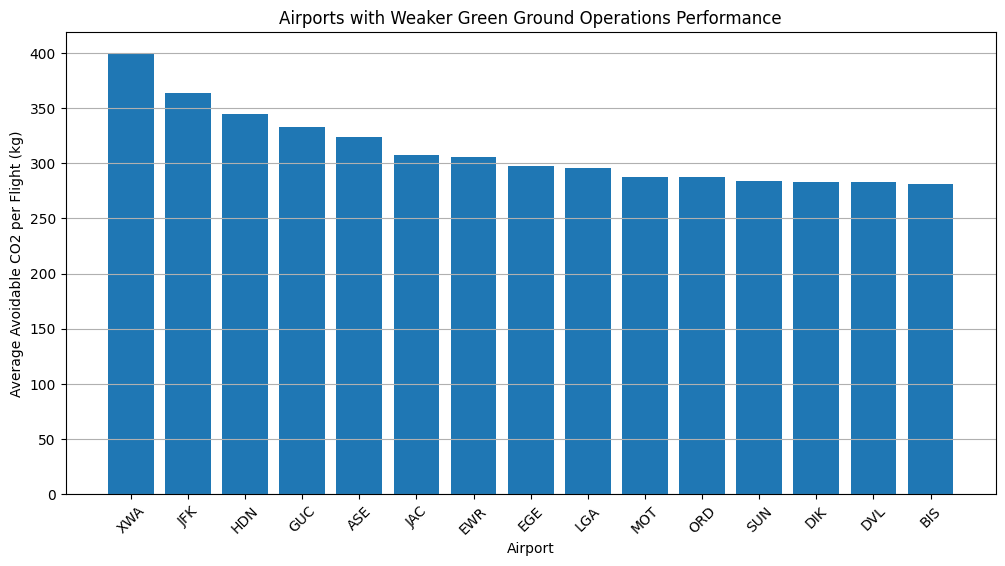

In [0]:
# Convert the top 15 airports with the highest avoidable CO2 into a Pandas DataFrame
worst_pd = airport_green_eda.limit(15).toPandas()

# Create a bar chart to compare avoidable CO2 per flight by airport
plt.figure(figsize=(12, 6))
plt.bar(
    worst_pd["origin"],
    worst_pd["avg_avoidable_co2_per_flight_kg"]
)

# Add chart labels and title
plt.xlabel("Airport")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Airports with Weaker Green Ground Operations Performance")

# Rotate airport labels to make them easier to read
plt.xticks(rotation=45)

# Add horizontal grid lines for easier comparison
plt.grid(axis="y")

# Display the chart
plt.show()

In [0]:
# Select the top 15 airports with the lowest avoidable CO2 per flight
best_green_airports = (
    airport_green_eda

    # Keep only airports with enough flights for reliable comparison
    .filter(F.col("total_flights") >= min_flights)

    # Rank airports from best to worst green ground operations performance
    .orderBy("avg_avoidable_co2_per_flight_kg")

    # Keep the best 15 airports
    .limit(15)
)

# Display the best-performing green airports
display(best_green_airports)

origin,origin_airport_name,origin_airport_state,total_flights,avg_taxi_out_min,avg_baseline_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,delay_rate,avg_hourly_departure_count,total_ground_co2_tonnes,total_avoidable_co2_tonnes,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg,avoidable_co2_share
SPN,Saipan International Airport,null,1115,11.09,9.0,2.15,-1.97,0.0583,1.0,312.59,60.67,280.35,54.41,0.1941
ITO,Hilo International Airport,null,20452,10.23,8.0,2.32,2.67,0.1095,1.64,5290.48,1201.47,258.68,58.75,0.2271
BRO,Brownsville South Padre Island International Airport,null,4734,12.9,10.0,3.25,9.56,0.1599,1.09,1544.3,389.39,326.22,82.25,0.2521
BLV,Scott AFB/Midamerica Airport,null,3389,12.06,10.0,2.33,18.64,0.2508,1.11,1537.16,297.07,453.57,87.66,0.1933
PSG,Petersburg James A Johnson Airport,null,2110,11.18,8.0,3.48,-1.49,0.1289,1.0,596.38,185.81,282.64,88.06,0.3116
LBE,Arnold Palmer Regional Airport,null,1583,11.32,9.0,2.57,9.93,0.2123,1.0,602.41,141.11,380.55,89.14,0.2342
DAB,Daytona Beach International Airport,null,8590,15.08,12.0,3.46,10.02,0.1681,1.41,3336.87,767.11,388.46,89.3,0.2299
BET,Bethel Airport,null,2119,11.22,8.0,3.69,10.94,0.2836,1.0,600.86,197.87,283.56,93.38,0.3293
MFE,McAllen Miller International Airport,null,12317,13.96,10.74,3.59,14.51,0.1864,1.51,4589.37,1178.05,372.6,95.64,0.2567
WRG,Wrangell Airport,null,2110,7.67,4.0,3.79,-0.85,0.1341,1.0,409.33,202.21,194.0,95.84,0.494


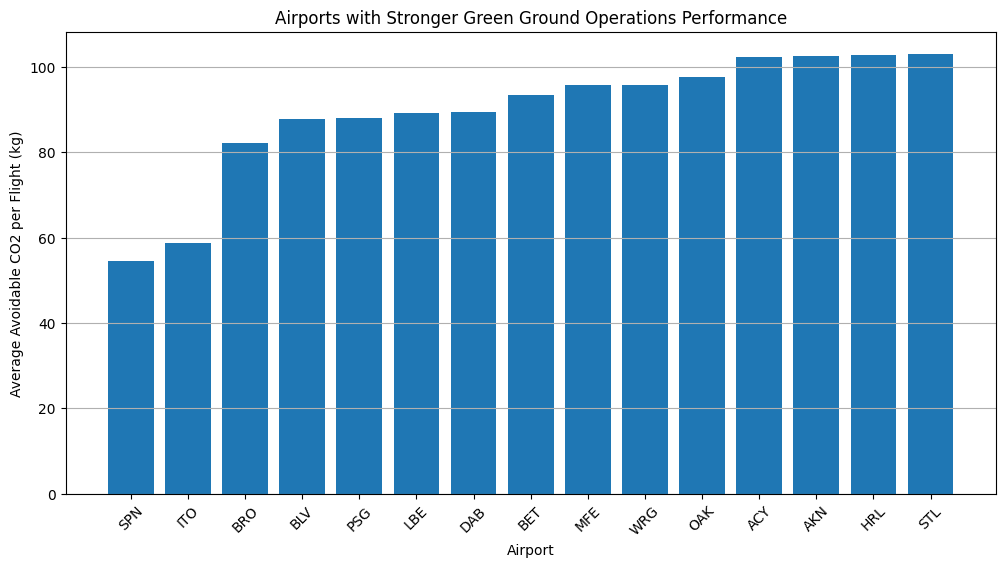

In [0]:
# Convert the best-performing green airports table into a Pandas DataFrame
best_pd = best_green_airports.toPandas()

# Create a bar chart to compare the lowest avoidable CO2 per flight by airport
plt.figure(figsize=(12, 6))
plt.bar(
    best_pd["origin"],
    best_pd["avg_avoidable_co2_per_flight_kg"]
)

# Add chart labels and title
plt.xlabel("Airport")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Airports with Stronger Green Ground Operations Performance")

# Rotate airport labels to make them easier to read
plt.xticks(rotation=45)

# Add horizontal grid lines for easier comparison
plt.grid(axis="y")

# Display the chart
plt.show()

In [0]:
# Build monthly airport-level emissions and operations summary
airport_month_emissions = (
    df.groupBy(
        "month",
        "origin",
        "origin_airport_name"
    )
    .agg(
        # Count total flights per airport and month
        F.count("*").alias("total_flights"),

        # Calculate monthly taxi-out efficiency metrics
        F.round(F.avg("taxi_out"), 2).alias("avg_taxi_out_min"),
        F.round(F.avg("excess_taxi_out_min"), 2).alias("avg_excess_taxi_out_min"),

        # Calculate monthly delay and congestion metrics
        F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay_min"),
        F.round(F.avg("airport_hour_departure_count"), 2).alias("avg_hourly_departure_count"),

        # Calculate monthly total emissions in tonnes
        F.round(F.sum("estimated_ground_co2_kg") / 1000, 2).alias("total_ground_co2_tonnes"),
        F.round(F.sum("avoidable_ground_co2_kg") / 1000, 2).alias("total_avoidable_co2_tonnes"),

        # Calculate monthly average emissions per flight in kilograms
        F.round(F.avg("estimated_ground_co2_kg"), 2).alias("avg_ground_co2_per_flight_kg"),
        F.round(F.avg("avoidable_ground_co2_kg"), 2).alias("avg_avoidable_co2_per_flight_kg")
    )

    # Sort results by airport and month for trend analysis
    .orderBy("origin", "month")
)

# Display the monthly airport emissions summary
display(airport_month_emissions)

month,origin,origin_airport_name,total_flights,avg_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,avg_hourly_departure_count,total_ground_co2_tonnes,total_avoidable_co2_tonnes,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg
1,ABE,Lehigh Valley International Airport,858,17.07,6.7,12.0,1.65,497.71,198.21,580.08,231.01
2,ABE,Lehigh Valley International Airport,846,17.21,6.84,9.62,1.75,495.63,199.17,585.85,235.42
3,ABE,Lehigh Valley International Airport,1044,15.42,5.17,9.07,1.95,560.96,191.77,537.32,183.69
4,ABE,Lehigh Valley International Airport,926,14.67,4.4,8.89,2.0,466.91,140.83,504.22,152.09
5,ABE,Lehigh Valley International Airport,959,14.97,4.67,12.56,1.82,493.77,154.8,514.88,161.42
6,ABE,Lehigh Valley International Airport,1020,14.65,4.49,11.58,2.06,524.05,162.65,513.78,159.46
7,ABE,Lehigh Valley International Airport,1019,15.15,4.92,15.34,1.76,535.91,177.81,525.92,174.49
8,ABE,Lehigh Valley International Airport,1019,13.89,3.59,13.4,1.85,480.81,125.43,471.85,123.09
9,ABE,Lehigh Valley International Airport,933,14.4,3.92,4.29,1.82,445.76,122.38,477.77,131.17
10,ABE,Lehigh Valley International Airport,1039,14.21,3.86,4.0,1.87,501.83,138.36,483.0,133.16


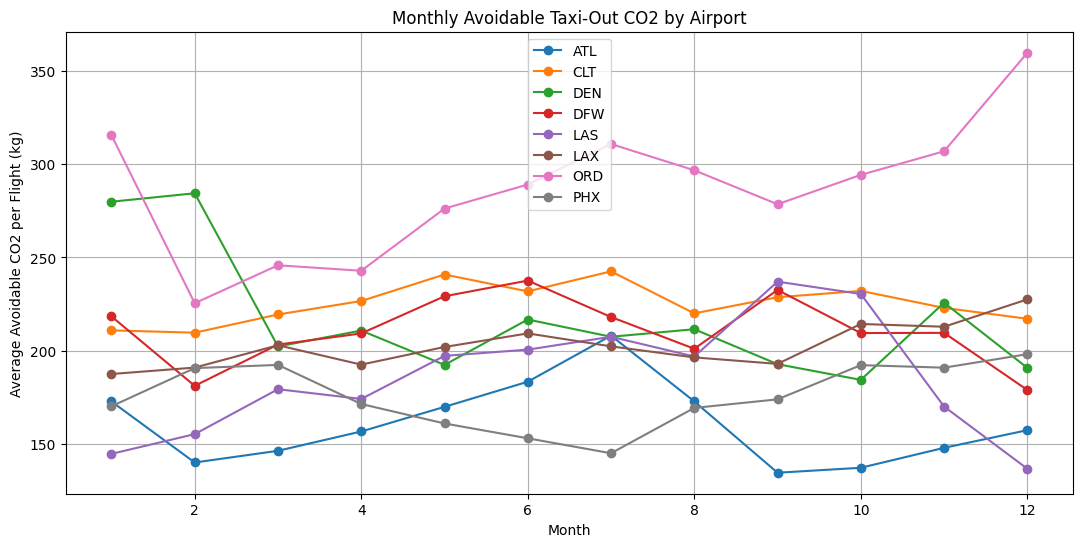

In [0]:
# Select the top 8 airports by total flight volume
top_airports = (
    df.groupBy("origin")
      .agg(F.count("*").alias("total_flights"))
      .orderBy(F.desc("total_flights"))
      .limit(8)
)

# Keep monthly emissions records only for the top airports
monthly_top_airports = (
    airport_month_emissions
    .join(top_airports.select("origin"), "origin", "inner")
    .orderBy("origin", "month")
)

# Convert to Pandas for plotting with Matplotlib
monthly_pd = monthly_top_airports.toPandas()

# Create a line chart showing monthly avoidable CO2 trends by airport
plt.figure(figsize=(13, 6))

for airport in monthly_pd["origin"].unique():
    # Filter data for one airport at a time
    airport_data = monthly_pd[monthly_pd["origin"] == airport]

    # Plot monthly avoidable CO2 per flight
    plt.plot(
        airport_data["month"],
        airport_data["avg_avoidable_co2_per_flight_kg"],
        marker="o",
        label=airport
    )

# Add chart labels and title
plt.xlabel("Month")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Monthly Avoidable Taxi-Out CO2 by Airport")

# Add legend and grid for readability
plt.legend()
plt.grid(True)

# Display the chart
plt.show()

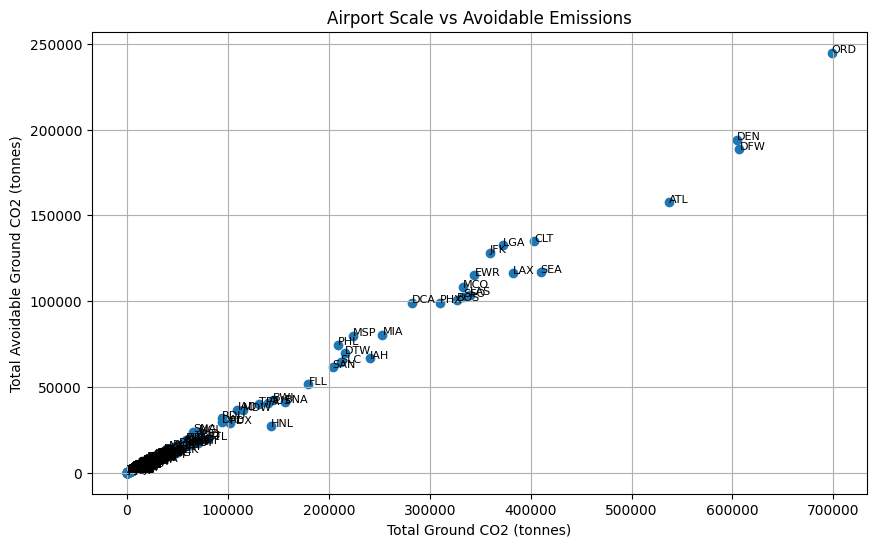

In [0]:
# Prepare airport-level data for the emissions scatter plot
airport_scatter_pd = (
    airport_green_eda

    # Keep only airports with enough flights for reliable comparison
    .filter(F.col("total_flights") >= min_flights)

    # Select emissions and flight volume metrics needed for the chart
    .select(
        "origin",
        "total_flights",
        "total_ground_co2_tonnes",
        "total_avoidable_co2_tonnes",
        "avg_avoidable_co2_per_flight_kg"
    )

    # Convert to Pandas for plotting with Matplotlib
    .toPandas()
)

# Create a scatter plot comparing total emissions against avoidable emissions
plt.figure(figsize=(10, 6))
plt.scatter(
    airport_scatter_pd["total_ground_co2_tonnes"],
    airport_scatter_pd["total_avoidable_co2_tonnes"]
)

# Add airport code labels to each point
for _, row in airport_scatter_pd.iterrows():
    plt.annotate(
        row["origin"],
        (
            row["total_ground_co2_tonnes"],
            row["total_avoidable_co2_tonnes"]
        ),
        fontsize=8
    )

# Add chart labels and title
plt.xlabel("Total Ground CO2 (tonnes)")
plt.ylabel("Total Avoidable Ground CO2 (tonnes)")
plt.title("Airport Scale vs Avoidable Emissions")

# Add grid for easier visual comparison
plt.grid(True)

# Display the chart
plt.show()

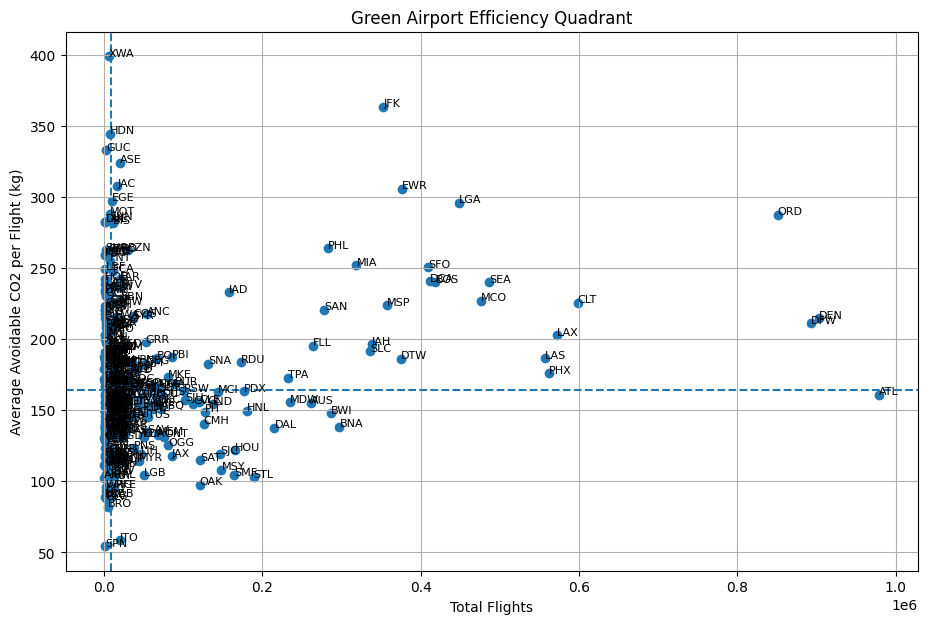

In [0]:
# Prepare airport data for the green efficiency quadrant chart
quadrant_pd = (
    airport_green_eda

    # Keep only airports with enough flights for reliable comparison
    .filter(F.col("total_flights") >= min_flights)

    # Select flight volume and avoidable CO2 efficiency metrics
    .select(
        "origin",
        "total_flights",
        "avg_avoidable_co2_per_flight_kg"
    )

    # Convert to Pandas for plotting with Matplotlib
    .toPandas()
)

# Calculate median values to split airports into four performance quadrants
x_median = quadrant_pd["total_flights"].median()
y_median = quadrant_pd["avg_avoidable_co2_per_flight_kg"].median()

# Create the quadrant scatter plot
plt.figure(figsize=(11, 7))
plt.scatter(
    quadrant_pd["total_flights"],
    quadrant_pd["avg_avoidable_co2_per_flight_kg"]
)

# Add median reference lines for quadrant separation
plt.axvline(x_median, linestyle="--")
plt.axhline(y_median, linestyle="--")

# Add airport code labels to each point
for _, row in quadrant_pd.iterrows():
    plt.annotate(
        row["origin"],
        (
            row["total_flights"],
            row["avg_avoidable_co2_per_flight_kg"]
        ),
        fontsize=8
    )

# Add chart labels and title
plt.xlabel("Total Flights")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Green Airport Efficiency Quadrant")

# Add grid for easier visual interpretation
plt.grid(True)

# Display the chart
plt.show()

In [0]:
# Analyze how airport congestion affects taxi out time, delays, and emissions
congestion_eda = (
    df.withColumn(
        "congestion_level",

        # Classify airport-hour traffic volume into congestion categories
        F.when(F.col("airport_hour_departure_count").isNull(), "Missing")
         .when(F.col("airport_hour_departure_count") < 5, "Low congestion")
         .when(F.col("airport_hour_departure_count") < 15, "Medium congestion")
         .otherwise("High congestion")
    )

    # Group flights by congestion level
    .groupBy("congestion_level")

    .agg(
        # Count flights in each congestion category
        F.count("*").alias("total_flights"),

        # Calculate average traffic volume per airport-hour
        F.round(F.avg("airport_hour_departure_count"), 2).alias("avg_hourly_departure_count"),

        # Calculate taxi-out and excess taxi-out performance
        F.round(F.avg("taxi_out"), 2).alias("avg_taxi_out_min"),
        F.round(F.avg("excess_taxi_out_min"), 2).alias("avg_excess_taxi_out_min"),

        # Calculate average departure delay
        F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay_min"),

        # Calculate average emissions per flight
        F.round(F.avg("estimated_ground_co2_kg"), 2).alias("avg_ground_co2_per_flight_kg"),
        F.round(F.avg("avoidable_ground_co2_kg"), 2).alias("avg_avoidable_co2_per_flight_kg")
    )

    # Sort congestion levels by actual average departure volume
    .orderBy("avg_hourly_departure_count")
)

# Display congestion impact summary
display(congestion_eda)

congestion_level,total_flights,avg_hourly_departure_count,avg_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg
Low congestion,3550465,2.33,15.59,5.05,11.96,498.96,158.49
Medium congestion,5176488,9.12,15.61,4.59,11.97,540.0,156.29
High congestion,11861183,35.72,19.74,6.45,13.33,695.29,226.05


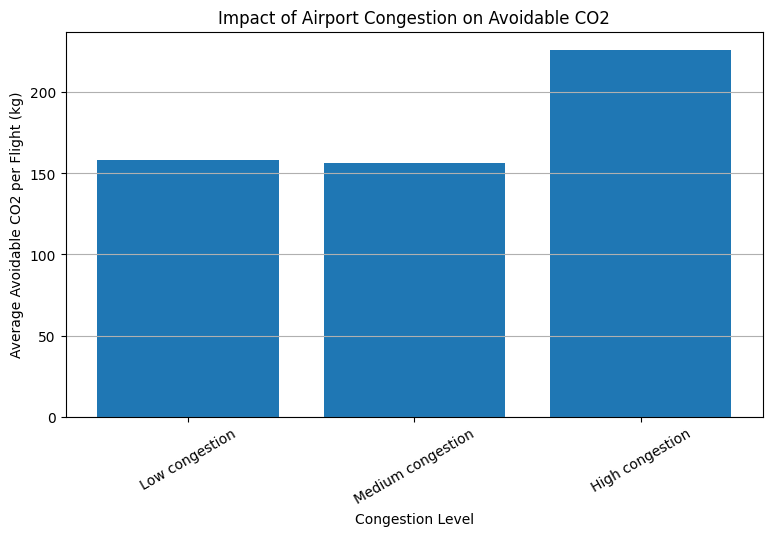

In [0]:
# Convert the congestion EDA summary into a Pandas DataFrame for plotting
congestion_pd = congestion_eda.toPandas()

# Create a bar chart showing avoidable CO2 by congestion level
plt.figure(figsize=(9, 5))
plt.bar(
    congestion_pd["congestion_level"],
    congestion_pd["avg_avoidable_co2_per_flight_kg"]
)

# Add chart labels and title
plt.xlabel("Congestion Level")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Impact of Airport Congestion on Avoidable CO2")

# Rotate x-axis labels for better readability
plt.xticks(rotation=30)

# Add horizontal grid lines for easier comparison
plt.grid(axis="y")

# Display the chart
plt.show()

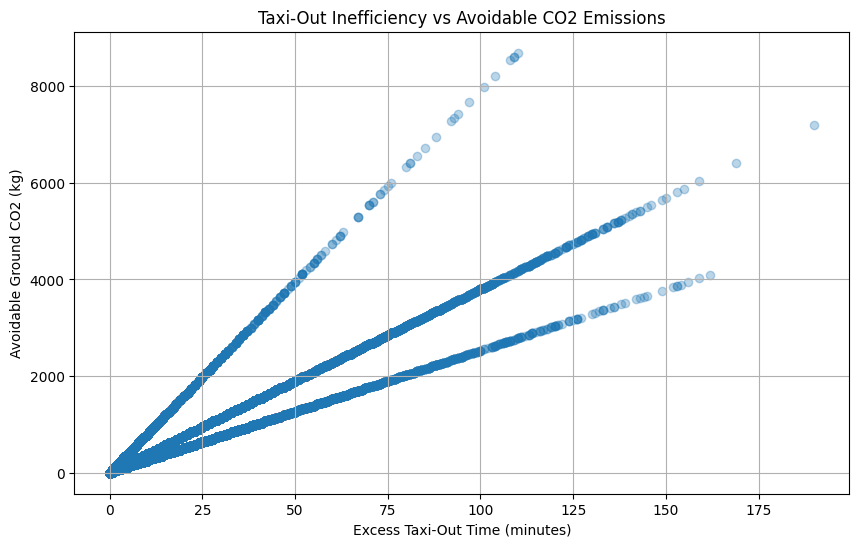

In [0]:
# Prepare a sample of taxi-out and emissions data for scatter plot analysis
taxi_emissions_pd = (
    df.select(
        "taxi_out",
        "excess_taxi_out_min",
        "estimated_ground_co2_kg",
        "avoidable_ground_co2_kg"
    )

    # Keep only complete records needed for the chart
    .filter(
        "taxi_out IS NOT NULL AND excess_taxi_out_min IS NOT NULL "
        "AND estimated_ground_co2_kg IS NOT NULL AND avoidable_ground_co2_kg IS NOT NULL"
    )

    # Sample 3% of records to make plotting faster and easier to read
    .sample(0.03, seed=42)

    # Convert to Pandas for Matplotlib plotting
    .toPandas()
)

# Create a scatter plot showing how excess taxi-out time drives avoidable CO2
plt.figure(figsize=(10, 6))
plt.scatter(
    taxi_emissions_pd["excess_taxi_out_min"],
    taxi_emissions_pd["avoidable_ground_co2_kg"],
    alpha=0.3
)

# Add chart labels and title
plt.xlabel("Excess Taxi-Out Time (minutes)")
plt.ylabel("Avoidable Ground CO2 (kg)")
plt.title("Taxi-Out Inefficiency vs Avoidable CO2 Emissions")

# Add grid for easier visual comparison
plt.grid(True)

# Display the chart
plt.show()

In [0]:
# Analyze how weather conditions affect taxi-out time, delays, and emissions
weather_eda = (
    df.withColumn(
        "wind_group",

        # Classify wind speed into simple weather categories
        F.when(F.col("wind_speed").isNull(), "Missing")
         .when(F.col("wind_speed") < 5, "Low wind")
         .when(F.col("wind_speed") < 15, "Medium wind")
         .otherwise("High wind")
    )

    .withColumn(
        "rain_group",

        # Classify rainfall intensity into simple weather categories
        F.when(F.col("precipitation_1hr").isNull(), "Missing")
         .when(F.col("precipitation_1hr") == 0, "No rain")
         .when(F.col("precipitation_1hr") < 2, "Light rain")
         .otherwise("Heavy rain")
    )

    # Group flights by wind and rain conditions
    .groupBy("wind_group", "rain_group")

    .agg(
        # Count flights in each weather condition group
        F.count("*").alias("total_flights"),

        # Calculate taxi-out and excess taxi-out performance
        F.round(F.avg("taxi_out"), 2).alias("avg_taxi_out_min"),
        F.round(F.avg("excess_taxi_out_min"), 2).alias("avg_excess_taxi_out_min"),

        # Calculate average departure delay
        F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay_min"),

        # Calculate average emissions per flight
        F.round(F.avg("estimated_ground_co2_kg"), 2).alias("avg_ground_co2_per_flight_kg"),
        F.round(F.avg("avoidable_ground_co2_kg"), 2).alias("avg_avoidable_co2_per_flight_kg")
    )

    # Show the weather groups with the highest avoidable emissions first
    .orderBy(F.desc("avg_avoidable_co2_per_flight_kg"))
)

# Display weather impact summary
display(weather_eda)

wind_group,rain_group,total_flights,avg_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg
Missing,Heavy rain,22,27.77,13.18,79.0,1329.5,628.41
High wind,Light rain,410,29.16,15.98,52.21,1065.58,581.87
High wind,Heavy rain,159,25.09,10.77,92.37,1013.94,433.6
Medium wind,Light rain,177784,24.08,9.78,24.22,862.74,349.01
High wind,No rain,908,22.63,8.49,24.61,875.34,332.88
High wind,Missing,65,24.12,10.14,153.45,797.49,332.33
Medium wind,Heavy rain,25384,22.95,8.9,34.76,827.4,321.8
Low wind,Light rain,273792,22.35,8.31,19.44,803.68,296.62
Low wind,Heavy rain,32491,21.74,7.97,30.1,776.03,283.93
Medium wind,Missing,38169,21.86,7.12,14.26,785.71,254.68


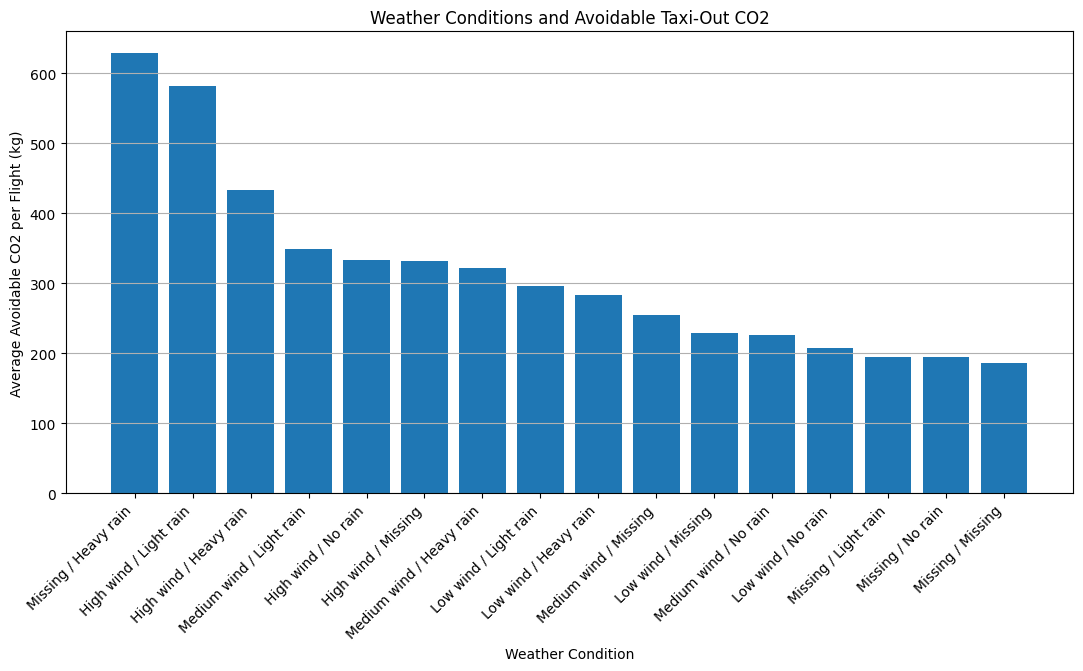

In [0]:
# Convert the weather EDA summary into a Pandas DataFrame for plotting
weather_pd = weather_eda.toPandas()

# Combine wind and rain groups into one readable weather condition label
weather_pd["weather_condition"] = (
    weather_pd["wind_group"] + " / " + weather_pd["rain_group"]
)

# Create a bar chart showing avoidable CO2 by weather condition
plt.figure(figsize=(13, 6))
plt.bar(
    weather_pd["weather_condition"],
    weather_pd["avg_avoidable_co2_per_flight_kg"]
)

# Add chart labels and title
plt.xlabel("Weather Condition")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Weather Conditions and Avoidable Taxi-Out CO2")

# Rotate labels so long weather condition names remain readable
plt.xticks(rotation=45, ha="right")

# Add horizontal grid lines for easier comparison
plt.grid(axis="y")

# Display the chart
plt.show()

In [0]:
# Group the data by airline to compare operational efficiency across carriers
airline_eda = (
    df.groupBy("airline")
    
    # Calculate flight volume, taxi-out performance,
    # departure delay, and emissions-related indicators for each airline
    .agg(
        F.count("*").alias("total_flights"),
        F.round(F.avg("taxi_out"), 2).alias("avg_taxi_out_min"),
        F.round(F.avg("excess_taxi_out_min"), 2).alias("avg_excess_taxi_out_min"),
        F.round(F.avg("dep_delay"), 2).alias("avg_dep_delay_min"),
        F.round(F.avg("estimated_ground_co2_kg"), 2).alias("avg_ground_co2_per_flight_kg"),
        F.round(F.avg("avoidable_ground_co2_kg"), 2).alias("avg_avoidable_co2_per_flight_kg")
    )
    
    # Keep only airlines with enough flights to make the comparison reliable
    .filter(F.col("total_flights") >= 500)
    
    # Rank airlines by the highest avoidable CO2 per flight
    # This highlights where operational improvements could have the biggest impact
    .orderBy(F.desc("avg_avoidable_co2_per_flight_kg"))
)

# Display the airline-level EDA table
display(airline_eda)

airline,total_flights,avg_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg
AS,724893,20.46,7.15,7.26,865.21,299.31
OH,651427,22.16,9.32,14.46,657.16,277.03
UA,2252227,20.58,7.07,12.17,767.9,261.47
OO,2223949,20.45,8.12,11.0,614.66,243.83
YX,915840,21.47,7.98,5.81,652.44,242.36
9E,391977,20.45,7.62,7.63,622.63,233.5
F9,571133,18.87,6.51,20.02,675.3,231.78
B6,730301,19.46,6.08,19.59,745.98,231.06
AA,2847015,18.52,5.65,19.0,668.47,202.86
DL,2983184,17.36,5.13,10.62,625.56,185.41


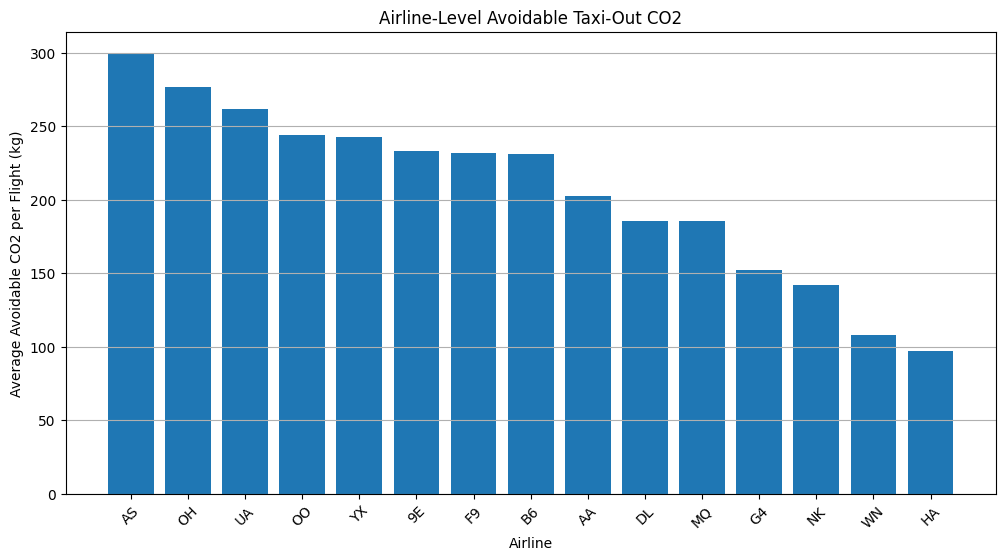

In [0]:
# Convert the top 15 airlines to Pandas for plotting
airline_pd = airline_eda.limit(15).toPandas()

# Create a bar chart comparing average avoidable taxi-out CO2 by airline
plt.figure(figsize=(12, 6))
plt.bar(
    airline_pd["airline"],
    airline_pd["avg_avoidable_co2_per_flight_kg"]
)

# Add chart labels and title
plt.xlabel("Airline")
plt.ylabel("Average Avoidable CO2 per Flight (kg)")
plt.title("Airline-Level Avoidable Taxi-Out CO2")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add gridlines to make comparison easier
plt.grid(axis="y")

# Display the chart
plt.show()

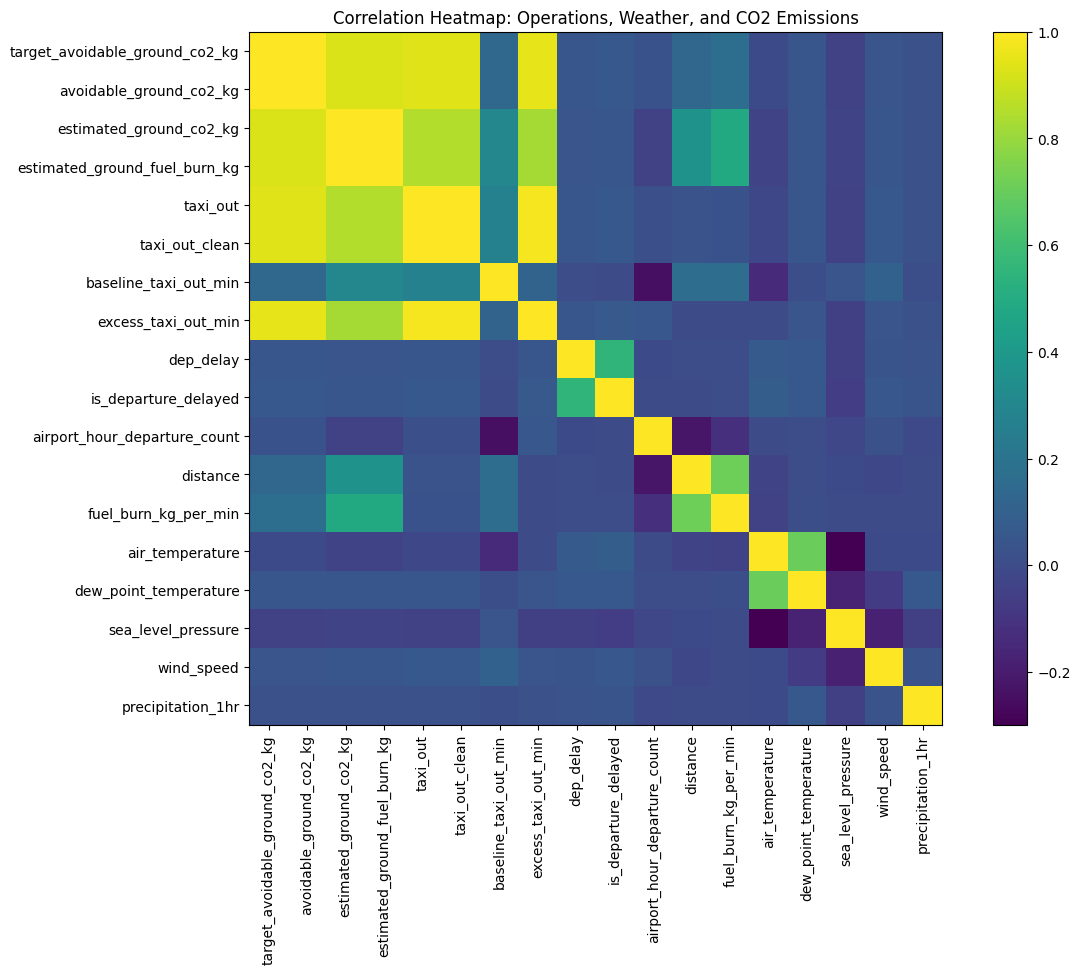

In [0]:
# Define numeric columns for correlation analysis
numeric_cols = [
    "target_avoidable_ground_co2_kg",
    "avoidable_ground_co2_kg",
    "estimated_ground_co2_kg",
    "estimated_ground_fuel_burn_kg",
    "taxi_out",
    "taxi_out_clean",
    "baseline_taxi_out_min",
    "excess_taxi_out_min",
    "dep_delay",
    "is_departure_delayed",
    "airport_hour_departure_count",
    "distance",
    "fuel_burn_kg_per_min",
    "air_temperature",
    "dew_point_temperature",
    "sea_level_pressure",
    "wind_speed",
    "precipitation_1hr"
]

# Select numeric columns, remove missing values, and sample the data for faster plotting
corr_pd = (
    df.select(numeric_cols)
      .dropna()
      .sample(0.05, seed=42)
      .toPandas()
)

# Calculate the correlation matrix
corr_matrix = corr_pd.corr()

# Create the correlation heatmap
plt.figure(figsize=(13, 9))
plt.imshow(corr_matrix)
plt.colorbar()

# Add column names to the x-axis
plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

# Add column names to the y-axis
plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

# Add a descriptive title linked to airport operations, weather, and emissions
plt.title("Correlation Heatmap: Operations, Weather, and CO2 Emissions")

# Display the heatmap
plt.show()

In [0]:
# Prepare the airport-level scoring dataset
score_base = (
    airport_green_eda
    
    # Keep only airports with enough flight volume for reliable scoring
    .filter(F.col("total_flights") >= min_flights)
    
    # Replace missing values in the scoring inputs with zero
    .fillna({
        "avg_avoidable_co2_per_flight_kg": 0,
        "avg_excess_taxi_out_min": 0,
        "delay_rate": 0,
        "avg_hourly_departure_count": 0
    })
)

# Create the airport green operations score
airport_green_score = (
    score_base
    
    # Rank airports by avoidable CO2 emissions
    .withColumn(
        "co2_rank",
        F.percent_rank().over(Window.orderBy("avg_avoidable_co2_per_flight_kg"))
    )
    
    # Rank airports by excess taxi-out time
    .withColumn(
        "taxi_rank",
        F.percent_rank().over(Window.orderBy("avg_excess_taxi_out_min"))
    )
    
    # Rank airports by departure delay rate
    .withColumn(
        "delay_rank",
        F.percent_rank().over(Window.orderBy("delay_rate"))
    )
    
    # Rank airports by hourly departure congestion
    .withColumn(
        "congestion_rank",
        F.percent_rank().over(Window.orderBy("avg_hourly_departure_count"))
    )
    
    # Combine the ranked indicators into one green operations score
    # Higher scores represent greener and more efficient airport operations
    .withColumn(
        "green_operations_score",
        F.round(
            100 * (
                1 - (
                    0.45 * F.col("co2_rank") +
                    0.25 * F.col("taxi_rank") +
                    0.20 * F.col("delay_rank") +
                    0.10 * F.col("congestion_rank")
                )
            ),
            2
        )
    )
    
    # Select the final airport-level performance columns
    .select(
        "origin",
        "origin_airport_name",
        "origin_airport_state",
        "total_flights",
        "avg_taxi_out_min",
        "avg_excess_taxi_out_min",
        "avg_dep_delay_min",
        "delay_rate",
        "avg_hourly_departure_count",
        "avg_ground_co2_per_flight_kg",
        "avg_avoidable_co2_per_flight_kg",
        "total_ground_co2_tonnes",
        "total_avoidable_co2_tonnes",
        "avoidable_co2_share",
        "green_operations_score"
    )
    
    # Rank airports from highest to lowest green operations score
    .orderBy(F.desc("green_operations_score"))
)

# Display the final airport green operations scoring table
display(airport_green_score)

origin,origin_airport_name,origin_airport_state,total_flights,avg_taxi_out_min,avg_excess_taxi_out_min,avg_dep_delay_min,delay_rate,avg_hourly_departure_count,avg_ground_co2_per_flight_kg,avg_avoidable_co2_per_flight_kg,total_ground_co2_tonnes,total_avoidable_co2_tonnes,avoidable_co2_share,green_operations_score
SPN,Saipan International Airport,null,1115,11.09,2.15,-1.97,0.0583,1.0,280.35,54.41,312.59,60.67,0.1941,99.82
SCC,Deadhorse Airport,null,1488,10.67,2.92,-7.07,0.0941,1.0,404.61,110.91,602.06,165.03,0.2741,95.9
PSG,Petersburg James A Johnson Airport,null,2110,11.18,3.48,-1.49,0.1289,1.0,282.64,88.06,596.38,185.81,0.3116,95.37
WRG,Wrangell Airport,null,2110,7.67,3.79,-0.85,0.1341,1.0,194.0,95.84,409.33,202.21,0.494,93.34
ITO,Hilo International Airport,null,20452,10.23,2.32,2.67,0.1095,1.64,258.68,58.75,5290.48,1201.47,0.2271,93.32
AKN,King Salmon Airport,null,555,10.65,4.05,-5.32,0.1387,1.0,269.24,102.49,149.43,56.88,0.3806,91.63
CLD,McClellan-Palomar Airport,null,637,13.93,4.42,1.59,0.0832,1.0,352.13,111.72,224.31,71.16,0.3172,90.97
BRO,Brownsville South Padre Island International Airport,null,4734,12.9,3.25,9.56,0.1599,1.09,326.22,82.25,1544.3,389.39,0.2521,88.6
OTZ,Ralph Wien Memorial Airport,null,1187,9.1,3.54,-5.11,0.0918,1.0,345.05,134.14,409.57,159.23,0.3888,88.25
ADQ,Kodiak Airport,null,2394,9.09,4.38,2.41,0.1454,1.0,229.82,110.79,550.19,265.24,0.4821,88.22


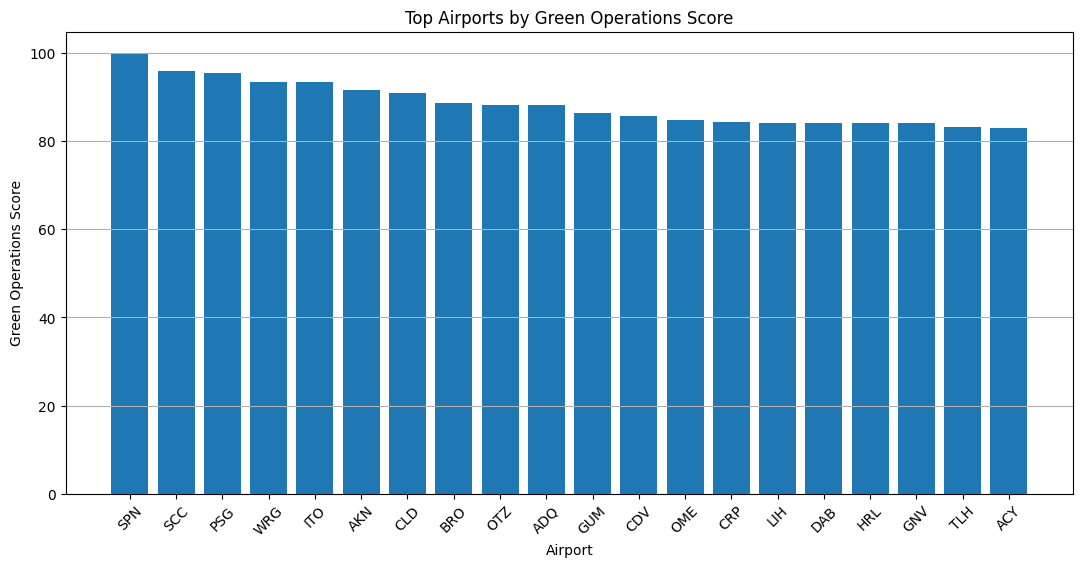

In [0]:
# Convert the top 20 airports to Pandas for plotting
green_score_pd = airport_green_score.limit(20).toPandas()

# Create a bar chart comparing airports by green operations score
plt.figure(figsize=(13, 6))
plt.bar(
    green_score_pd["origin"],
    green_score_pd["green_operations_score"]
)

# Add chart labels and title
plt.xlabel("Airport")
plt.ylabel("Green Operations Score")
plt.title("Top Airports by Green Operations Score")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add gridlines to make comparison easier
plt.grid(axis="y")

# Display the chart
plt.show()

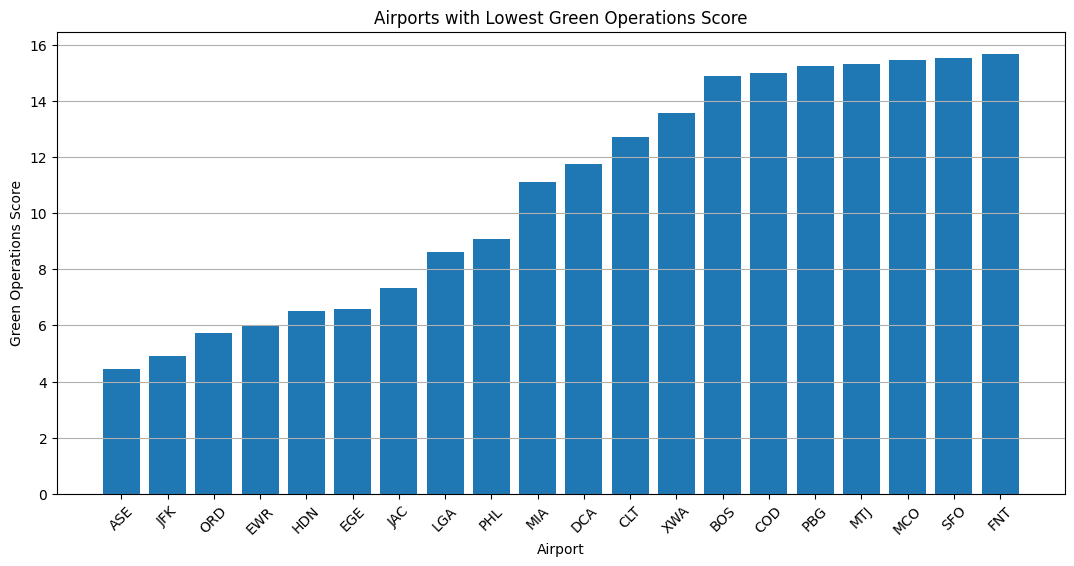

In [0]:
# Convert the 20 lowest-scoring airports to Pandas for plotting
low_score_pd = (
    airport_green_score
    .orderBy("green_operations_score")
    .limit(20)
    .toPandas()
)

# Create a bar chart showing airports with the lowest green operations scores
plt.figure(figsize=(13, 6))
plt.bar(
    low_score_pd["origin"],
    low_score_pd["green_operations_score"]
)

# Add chart labels and title
plt.xlabel("Airport")
plt.ylabel("Green Operations Score")
plt.title("Airports with Lowest Green Operations Score")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

# Add gridlines to make comparison easier
plt.grid(axis="y")

# Display the chart
plt.show()

In [0]:
# Save the airport-level emissions EDA table as a Gold Delta table
(
    airport_green_eda.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(table_name("gold_airport_emissions_eda"))
)

# Save the monthly airport emissions table as a partitioned Gold Delta table
(
    airport_month_emissions.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("month")
    .saveAsTable(table_name("gold_airport_month_emissions"))
)

# Save the airport green operations scoring table as a Gold Delta table
(
    airport_green_score.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(table_name("gold_airport_green_operations_score"))
)

# Print the names of the created Gold EDA tables
print("Created Gold EDA tables:")
print(table_name("gold_airport_emissions_eda"))
print(table_name("gold_airport_month_emissions"))
print(table_name("gold_airport_green_operations_score"))

Created Gold EDA tables:
`new`.`airgreenops`.`gold_airport_emissions_eda`
`new`.`airgreenops`.`gold_airport_month_emissions`
`new`.`airgreenops`.`gold_airport_green_operations_score`


In [0]:
# Load the Silver feature table
silver = spark.table(table_name("silver_flight_weather_features"))

# Define the required columns for the Gold emissions table
required = [
    "year", "month", "scheduled_dep_hour", "origin", "dest", "airline",
    "aircraft_group", "taxi_out_clean", "fuel_burn_kg_per_min",
    "target_avoidable_ground_co2_kg", "avoidable_ground_co2_kg",
    "estimated_ground_co2_kg", "airport_hour_departure_count",
    "dep_delay", "wind_speed", "precipitation_1hr"
]

# Check that all required columns exist before continuing
missing = [c for c in required if c not in silver.columns]
if missing:
    raise Exception(f"Missing columns in Silver table: {missing}")

# Helper function to calculate approximate quantiles safely
def q(df, col, p, default=0.0):
    vals = df.where(F.col(col).isNotNull()).approxQuantile(col, [p], 0.01)
    return float(vals[0]) if vals else float(default)

# Keep only valid records needed for emissions modelling and dashboarding
base = silver.filter(
    F.col("year").isNotNull() &
    F.col("month").between(1, 12) &
    F.col("scheduled_dep_hour").between(0, 23) &
    F.col("origin").isNotNull() &
    F.col("dest").isNotNull() &
    F.col("airline").isNotNull() &
    F.col("aircraft_group").isNotNull() &
    (F.col("taxi_out_clean") > 0) &
    (F.col("fuel_burn_kg_per_min") > 0) &
    F.col("target_avoidable_ground_co2_kg").isNotNull() &
    (F.col("target_avoidable_ground_co2_kg") >= 0)
)

# Define weather columns used for missing-value handling and weather-risk features
weather_cols = [
    "air_temperature",
    "dew_point_temperature",
    "sea_level_pressure",
    "wind_direction",
    "wind_speed",
    "precipitation_1hr"
]

# Calculate median values for weather columns to support imputation
medians = {c: q(base, c, 0.5, 0.0) for c in weather_cols if c in base.columns}

# Calculate thresholds for outlier handling and classification labels
taxi_p99 = q(base, "taxi_out_clean", 0.99, 120)
target_p75 = q(base, "target_avoidable_ground_co2_kg", 0.75, 0)
target_p99 = q(base, "target_avoidable_ground_co2_kg", 0.99, 1000)
dep_p01 = q(base, "dep_delay", 0.01, -30)
dep_p99 = q(base, "dep_delay", 0.99, 180)
cong_med = q(base, "airport_hour_departure_count", 0.5, 0)

# Start building the cleaned Gold table
gold = base

# Add missing-value flags for weather columns
for c in weather_cols:
    gold = gold.withColumn(f"{c}_missing", F.col(c).isNull().cast("int"))

gold = (
    gold
    
    # Fill missing weather values using median values
    .fillna(medians)

    # Clean and winsorize departure delay values
    .withColumn("dep_delay_missing", F.col("dep_delay").isNull().cast("int"))
    .withColumn("dep_delay_cleaned", F.coalesce(F.col("dep_delay"), F.lit(0.0)))
    .withColumn(
        "dep_delay_winsorized",
        F.least(F.greatest(F.col("dep_delay_cleaned"), F.lit(dep_p01)), F.lit(dep_p99))
    )

    # Clean airport hourly departure count and preserve a missing-value flag
    .withColumn(
        "airport_hour_departure_count_missing",
        F.col("airport_hour_departure_count").isNull().cast("int")
    )
    .withColumn(
        "airport_hour_departure_count_cleaned",
        F.coalesce(F.col("airport_hour_departure_count"), F.lit(cong_med))
    )

    # Flag and cap extreme taxi-out values
    .withColumn("taxi_out_outlier_flag", (F.col("taxi_out_clean") > taxi_p99).cast("int"))
    .withColumn(
        "taxi_out_winsorized",
        F.least(F.col("taxi_out_clean"), F.lit(taxi_p99))
    )

    # Flag and cap extreme avoidable CO2 target values
    .withColumn(
        "avoidable_co2_outlier_flag",
        (F.col("target_avoidable_ground_co2_kg") > target_p99).cast("int")
    )
    .withColumn(
        "label_avoidable_ground_co2_kg",
        F.least(F.col("target_avoidable_ground_co2_kg"), F.lit(target_p99))
    )

    # Create a binary classification label for high avoidable emissions
    .withColumn(
        "high_avoidable_emissions_flag",
        (F.col("target_avoidable_ground_co2_kg") >= target_p75).cast("int")
    )

    # Create a season feature from the flight month
    .withColumn(
        "season",
        F.when(F.col("month").isin(12, 1, 2), "winter")
         .when(F.col("month").isin(3, 4, 5), "spring")
         .when(F.col("month").isin(6, 7, 8), "summer")
         .otherwise("fall")
    )

    # Create a time-of-day feature from the scheduled departure hour
    .withColumn(
        "time_of_day",
        F.when(F.col("scheduled_dep_hour").between(5, 11), "morning")
         .when(F.col("scheduled_dep_hour").between(12, 16), "afternoon")
         .when(F.col("scheduled_dep_hour").between(17, 21), "evening")
         .otherwise("night")
    )

    # Create a congestion level feature based on hourly airport departure count
    .withColumn(
        "congestion_level",
        F.when(F.col("airport_hour_departure_count_cleaned") < 5, "low")
         .when(F.col("airport_hour_departure_count_cleaned") < 15, "medium")
         .otherwise("high")
    )

    # Create a weather risk level using wind speed and precipitation
    .withColumn(
        "weather_risk_level",
        F.when(
            (F.col("wind_speed_missing") == 1) | (F.col("precipitation_1hr_missing") == 1),
            "unknown"
        )
        .when(
            (F.col("wind_speed") >= 15) | (F.col("precipitation_1hr") >= 2),
            "high"
        )
        .when(
            (F.col("wind_speed") >= 5) | (F.col("precipitation_1hr") > 0),
            "medium"
        )
        .otherwise("low")
    )
)

# Save the cleaned emissions dataset as a partitioned Gold Delta table
(
    gold.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .partitionBy("year", "month")
    .saveAsTable(table_name("gold_flight_emissions_clean"))
)

# Print validation details for the created Gold table
print("Created:", table_name("gold_flight_emissions_clean"))
print("Silver rows:", silver.count())
print("Gold rows:", gold.count())

# Display a sample of the Gold emissions table
display(gold.limit(10))

Created: `new`.`airgreenops`.`gold_flight_emissions_clean`
Silver rows: 20588136
Gold rows: 20588136


origin,aircraft_group,year,month,day,scheduled_dep_hour,flight_date,day_of_week,airline,tail_number,flight_number,dest,route,origin_city,dest_city,scheduled_dep_time,dep_delay,taxi_out,distance,distance_group,airport_hour_departure_count,station_id,air_temperature,dew_point_temperature,sea_level_pressure,wind_direction,wind_speed,precipitation_1hr,origin_airport_name,origin_airport_city,origin_airport_state,origin_airport_country,origin_latitude,origin_longitude,fuel_burn_kg_per_min,baseline_taxi_out_min,taxi_out_clean,excess_taxi_out_min,estimated_ground_fuel_burn_kg,estimated_ground_co2_kg,avoidable_ground_fuel_burn_kg,avoidable_ground_co2_kg,target_avoidable_ground_co2_kg,is_departure_delayed,air_temperature_missing,dew_point_temperature_missing,sea_level_pressure_missing,wind_direction_missing,wind_speed_missing,precipitation_1hr_missing,dep_delay_missing,dep_delay_cleaned,dep_delay_winsorized,airport_hour_departure_count_missing,airport_hour_departure_count_cleaned,taxi_out_outlier_flag,taxi_out_winsorized,avoidable_co2_outlier_flag,label_avoidable_ground_co2_kg,high_avoidable_emissions_flag,season,time_of_day,congestion_level,weather_risk_level
ABE,regional_jet,2025,7,11,20,2025-07-11,5,OH,N590NN,5052,CLT,ABE-CLT,"Allentown/Bethlehem/Easton, PA","Charlotte, NC",2003,-10.0,13.0,481.0,2,1,null,16.7,8.9,1015.5,190.0,3.6,0.0,Lehigh Valley International Airport,Allentown/Bethlehem,null,null,null,null,8.0,12.0,13.0,1.0,104.0,328.64,8.0,25.28,25.28,0,1,1,1,1,1,1,0,-10.0,-10.0,0,1.0,0,13.0,0,25.28,0,summer,evening,low,unknown
BTR,regional_jet,2025,7,15,18,2025-07-15,2,OH,N562NN,5494,DFW,BTR-DFW,"Baton Rouge, LA","Dallas/Fort Worth, TX",1821,41.0,14.0,383.0,2,1,null,16.7,8.9,1015.5,190.0,3.6,0.0,Baton Rouge Metropolitan Airport,Baton Rouge,null,null,null,null,8.0,11.0,14.0,3.0,112.0,353.92,24.0,75.84,75.84,1,1,1,1,1,1,1,0,41.0,41.0,0,1.0,0,14.0,0,75.84,0,summer,evening,low,unknown
BWI,narrow_body,2025,7,29,15,2025-07-29,2,WN,N494WN,1695,FLL,BWI-FLL,"Baltimore, MD","Fort Lauderdale, FL",1515,13.0,8.0,925.0,4,14,null,16.7,8.9,1015.5,190.0,3.6,0.0,Baltimore/Washington International Thurgood Marshall Airport,Baltimore,null,null,null,null,12.0,11.0,8.0,0.0,96.0,303.36,0.0,0.0,0.0,0,1,1,1,1,1,1,0,13.0,13.0,0,14.0,0,8.0,0,0.0,0,summer,afternoon,medium,unknown
BWI,regional_jet,2025,7,29,15,2025-07-29,2,WN,N8924Q,1718,ISP,BWI-ISP,"Baltimore, MD","Islip, NY",1550,13.0,23.0,220.0,1,14,null,16.7,8.9,1015.5,190.0,3.6,0.0,Baltimore/Washington International Thurgood Marshall Airport,Baltimore,null,null,null,null,8.0,11.0,23.0,12.0,184.0,581.44,96.0,303.36,303.36,0,1,1,1,1,1,1,0,13.0,13.0,0,14.0,0,23.0,0,303.36,1,summer,afternoon,medium,unknown
BWI,narrow_body,2025,7,29,15,2025-07-29,2,WN,N8899H,2344,LAX,BWI-LAX,"Baltimore, MD","Los Angeles, CA",1530,6.0,11.0,2329.0,10,14,null,16.7,8.9,1015.5,190.0,3.6,0.0,Baltimore/Washington International Thurgood Marshall Airport,Baltimore,null,null,null,null,12.0,11.0,11.0,0.0,132.0,417.12,0.0,0.0,0.0,0,1,1,1,1,1,1,0,6.0,6.0,0,14.0,0,11.0,0,0.0,0,summer,afternoon,medium,unknown
BWI,narrow_body,2025,7,29,15,2025-07-29,2,WN,N7824A,1774,MCO,BWI-MCO,"Baltimore, MD","Orlando, FL",1545,-2.0,15.0,787.0,4,14,null,16.7,8.9,1015.5,190.0,3.6,0.0,Baltimore/Washington International Thurgood Marshall Airport,Baltimore,null,null,null,null,12.0,11.0,15.0,4.0,180.0,568.8000000000001,48.0,151.68,151.68,0,1,1,1,1,1,1,0,-2.0,-2.0,0,14.0,0,15.0,0,151.68,0,summer,afternoon,medium,unknown
BWI,regional_jet,2025,7,29,15,2025-07-29,2,WN,N292WN,992,MYR,BWI-MYR,"Baltimore, MD","Myrtle Beach, SC",1500,11.0,20.0,399.0,2,14,null,16.7,8.9,1015.5,190.0,3.6,0.0,Baltimore/Washington International Thurgood Marshall Airport,Baltimore,null,null,null,null,8.0,11.0,20.0,9.0,160.0,505.6,72.0,227.52,227.52,0,1,1,1,1,1,1,0,11.0,11.0,0,14.0,0,20.0,0,227.52,0,summer,afternoon,medium,unknown
BWI,regional_jet,2025,7,29,15,2025-07-29,2,WN,N472WN,333,PVD,BWI-PVD,"Baltimore, MD","Providence, RI",1515,-1.0,13.0,327.0,2,14,null,16.7,8.9,1015.5,190.0,3.6,0.0,B

In [0]:
# Load the cleaned Gold emissions table
gold = spark.table(table_name("gold_flight_emissions_clean"))

# Print basic table validation details
print("Rows:", gold.count())
print("Columns:", len(gold.columns))

# Display a sample of the Gold table
display(gold.limit(10))

Rows: 20588136
Columns: 64


origin,aircraft_group,year,month,day,scheduled_dep_hour,flight_date,day_of_week,airline,tail_number,flight_number,dest,route,origin_city,dest_city,scheduled_dep_time,dep_delay,taxi_out,distance,distance_group,airport_hour_departure_count,station_id,air_temperature,dew_point_temperature,sea_level_pressure,wind_direction,wind_speed,precipitation_1hr,origin_airport_name,origin_airport_city,origin_airport_state,origin_airport_country,origin_latitude,origin_longitude,fuel_burn_kg_per_min,baseline_taxi_out_min,taxi_out_clean,excess_taxi_out_min,estimated_ground_fuel_burn_kg,estimated_ground_co2_kg,avoidable_ground_fuel_burn_kg,avoidable_ground_co2_kg,target_avoidable_ground_co2_kg,is_departure_delayed,air_temperature_missing,dew_point_temperature_missing,sea_level_pressure_missing,wind_direction_missing,wind_speed_missing,precipitation_1hr_missing,dep_delay_missing,dep_delay_cleaned,dep_delay_winsorized,airport_hour_departure_count_missing,airport_hour_departure_count_cleaned,taxi_out_outlier_flag,taxi_out_winsorized,avoidable_co2_outlier_flag,label_avoidable_ground_co2_kg,high_avoidable_emissions_flag,season,time_of_day,congestion_level,weather_risk_level
AVL,regional_jet,2025,5,8,19,2025-05-08,4,G4,191NV,237,SFB,AVL-SFB,"Asheville, NC","Sanford, FL",1951,1308.0,8.0,465.0,2,2,null,16.7,8.9,1015.5,190.0,3.6,0.0,Asheville Regional Airport,Asheville,null,null,null,null,8.0,11.0,8.0,0.0,64.0,202.24,0.0,0.0,0.0,1,1,1,1,1,1,1,0,1308.0,1308.0,0,2.0,0,8.0,0,0.0,0,spring,evening,low,unknown
AVL,narrow_body,2025,5,8,19,2025-05-08,4,G4,330NV,1012,PIE,AVL-PIE,"Asheville, NC","St. Petersburg, FL",1915,232.0,12.0,519.0,3,2,null,16.7,8.9,1015.5,190.0,3.6,0.0,Asheville Regional Airport,Asheville,null,null,null,null,12.0,10.0,12.0,2.0,144.0,455.04,24.0,75.84,75.84,1,1,1,1,1,1,1,0,232.0,232.0,0,2.0,0,12.0,0,75.84,0,spring,evening,low,unknown
BIL,narrow_body,2025,5,20,7,2025-05-20,2,MQ,N254NN,3746,DFW,BIL-DFW,"Billings, MT","Dallas/Fort Worth, TX",713,-12.0,11.0,1081.0,5,2,null,16.7,8.9,1015.5,190.0,3.6,0.0,Billings Logan International Airport,Billings,null,null,null,null,12.0,11.0,11.0,0.0,132.0,417.12,0.0,0.0,0.0,0,1,1,1,1,1,1,0,-12.0,-12.0,0,2.0,0,11.0,0,0.0,0,spring,morning,low,unknown
BIL,regional_jet,2025,5,20,7,2025-05-20,2,UA,N37434,372,DEN,BIL-DEN,"Billings, MT","Denver, CO",700,-11.0,20.0,455.0,2,2,null,16.7,8.9,1015.5,190.0,3.6,0.0,Billings Logan International Airport,Billings,null,null,null,null,8.0,12.0,20.0,8.0,160.0,505.6,64.0,202.24,202.24,0,1,1,1,1,1,1,0,-11.0,-11.0,0,2.0,0,20.0,0,202.24,0,spring,morning,low,unknown
CHS,regional_jet,2025,5,10,14,2025-05-10,6,YX,N109HQ,4450,DCA,CHS-DCA,"Charleston, SC","Washington, DC",1445,-6.0,12.0,444.0,2,3,null,16.7,8.9,1015.5,190.0,3.6,0.0,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,12.0,1.0,96.0,303.36,8.0,25.28,25.28,0,1,1,1,1,1,1,0,-6.0,-6.0,0,3.0,0,12.0,0,25.28,0,spring,afternoon,low,unknown
CHS,regional_jet,2025,5,10,14,2025-05-10,6,YX,N642RW,3401,IAD,CHS-IAD,"Charleston, SC","Washington, DC",1440,-7.0,9.0,441.0,2,3,null,16.7,8.9,1015.5,190.0,3.6,0.0,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,9.0,0.0,72.0,227.52,0.0,0.0,0.0,0,1,1,1,1,1,1,0,-7.0,-7.0,0,3.0,0,9.0,0,0.0,0,spring,afternoon,low,unknown
CHS,regional_jet,2025,5,10,14,2025-05-10,6,DL,N944AT,2179,ATL,CHS-ATL,"Charleston, SC","Atlanta, GA",1417,-8.0,13.0,259.0,2,3,null,16.7,8.9,1015.5,190.0,3.6,0.0,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,13.0,2.0,104.0,328.64,16.0,50.56,50.56,0,1,1,1,1,1,1,0,-8.0,-8.0,0,3.0,0,13.0,0,50.56,0,spring,afternoon,low,unknown
CHS,regional_jet,2025,5,10,18,2025-05-10,6,WN,N8861Q,1330,BWI,CHS-BWI,"Charleston, SC","Baltimore, MD",1850,1.0,13.0,472.0,2,7,null,16.7,8.9,1015.5,190.0,3.6,0.0,Charleston International Airport,Charleston,null,null,null,null,8.0,11.0,13.0,2.0,104.0,328.64,16.0,50.56,50.56,0,1,1,1,1,1,1,0,1.0,1.0,0,7.0,0,13.0,0,50.56,0,spring,evening,medium,unknown
CHS,narrow_body,2025,5,10,18,2025-05-10,6,WN,N88

In [0]:
# Build a list of null-count calculations for every column
null_counts = []

for c in gold.columns:
    null_counts.append(
        F.sum(F.col(c).isNull().cast("int")).alias(c)
    )

# Create a one-row summary table showing null counts by column
null_df = gold.select(null_counts)

# Display the null-count validation table
display(null_df)

origin,aircraft_group,year,month,day,scheduled_dep_hour,flight_date,day_of_week,airline,tail_number,flight_number,dest,route,origin_city,dest_city,scheduled_dep_time,dep_delay,taxi_out,distance,distance_group,airport_hour_departure_count,station_id,air_temperature,dew_point_temperature,sea_level_pressure,wind_direction,wind_speed,precipitation_1hr,origin_airport_name,origin_airport_city,origin_airport_state,origin_airport_country,origin_latitude,origin_longitude,fuel_burn_kg_per_min,baseline_taxi_out_min,taxi_out_clean,excess_taxi_out_min,estimated_ground_fuel_burn_kg,estimated_ground_co2_kg,avoidable_ground_fuel_burn_kg,avoidable_ground_co2_kg,target_avoidable_ground_co2_kg,is_departure_delayed,air_temperature_missing,dew_point_temperature_missing,sea_level_pressure_missing,wind_direction_missing,wind_speed_missing,precipitation_1hr_missing,dep_delay_missing,dep_delay_cleaned,dep_delay_winsorized,airport_hour_departure_count_missing,airport_hour_departure_count_cleaned,taxi_out_outlier_flag,taxi_out_winsorized,avoidable_co2_outlier_flag,label_avoidable_ground_co2_kg,high_avoidable_emissions_flag,season,time_of_day,congestion_level,weather_risk_level
0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,15013431,0,0,0,0,0,0,0,0,20588136,20588136,20588136,20588136,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [0]:
# Generate descriptive statistics for the avoidable ground CO2 label
display(
    gold.select(
        
        # Count the total number of rows in the Gold dataset
        F.count("*").alias("rows"),
        
        # Calculate minimum label value
        F.min("label_avoidable_ground_co2_kg").alias("min_label"),
        
        # Calculate key percentile distributions for emissions analysis
        F.expr("percentile_approx(label_avoidable_ground_co2_kg, 0.25)").alias("p25_label"),
        F.expr("percentile_approx(label_avoidable_ground_co2_kg, 0.50)").alias("median_label"),
        F.expr("percentile_approx(label_avoidable_ground_co2_kg, 0.75)").alias("p75_label"),
        F.expr("percentile_approx(label_avoidable_ground_co2_kg, 0.95)").alias("p95_label"),
        F.expr("percentile_approx(label_avoidable_ground_co2_kg, 0.99)").alias("p99_label"),
        
        # Calculate maximum label value
        F.max("label_avoidable_ground_co2_kg").alias("max_label")
    )
)

rows,min_label,p25_label,median_label,p75_label,p95_label,p99_label,max_label
20588136,0.0,0.0,101.12,252.8,733.12,1491.52,16432.0


In [0]:
# Count Gold table records by year and month to show partioning
display(
    gold.groupBy("year", "month")
        .agg(F.count("*").alias("rows"))
        .orderBy("year", "month")
)

year,month,rows
2023,1,527197
2023,2,492747
2023,3,571533
2023,4,550249
2023,5,575430
2023,6,562804
2023,7,585058
2023,8,592142
2023,9,560887
2023,10,596003


In [0]:
# Analyze average avoidable CO2 by weather risk level
display(
    gold.groupBy("weather_risk_level")
        .agg(
            F.count("*").alias("flights"),
            F.avg("label_avoidable_ground_co2_kg").alias("avg_avoidable_co2_kg")
        )
        .orderBy(F.desc("avg_avoidable_co2_kg"))
)

# Analyze average avoidable CO2 by congestion level
display(
    gold.groupBy("congestion_level")
        .agg(
            F.count("*").alias("flights"),
            F.avg("label_avoidable_ground_co2_kg").alias("avg_avoidable_co2_kg")
        )
        .orderBy(F.desc("avg_avoidable_co2_kg"))
)

weather_risk_level,flights,avg_avoidable_co2_kg
high,59352,303.332101361372
medium,1697606,243.9316428666054
low,3685526,212.009215770336
unknown,15145652,187.47621276117897


congestion_level,flights,avg_avoidable_co2_kg
high,11861183,226.04847722872933
low,3550465,158.4854388145834
medium,5176488,156.2871936189681


In [0]:
# Create airport level KPI summary from the cleaned Gold table
airport_kpi = (
    gold.groupBy("origin")
        .agg(
            F.count("*").alias("departures"),
            F.sum("label_avoidable_ground_co2_kg").alias("total_avoidable_ground_co2_kg"),
            F.avg("label_avoidable_ground_co2_kg").alias("avg_avoidable_ground_co2_kg"),
            F.avg("taxi_out_clean").alias("avg_taxi_out_min"),
            F.avg("airport_hour_departure_count_cleaned").alias("avg_hourly_departure_count")
        )
        
        # Rank airports by total avoidable ground CO2
        .orderBy(F.desc("total_avoidable_ground_co2_kg"))
)

# Display the top 25 airports by total avoidable ground CO2
display(airport_kpi.limit(25))

origin,departures,total_avoidable_ground_co2_kg,avg_avoidable_ground_co2_kg,avg_taxi_out_min,avg_hourly_departure_count
ORD,850994,2.447695615200295E8,287.6278346498677,24.216737133281786,53.591945419121636
DEN,902804,1.9402488796000147E8,214.91363347969377,18.707373915046897,54.082150721529814
DFW,893078,1.8857557539998624E8,211.15241378691024,19.721452101608147,54.98594971547838
ATL,979661,1.5767202359994906E8,160.9454940024652,16.46859883163666,55.21786924252369
CLT,598576,1.3500086271997303E8,225.53671166230023,21.078456202721124,42.52262369356606
LGA,448130,1.325677891199768E8,295.82440166910675,24.198172405328812,27.198205877758685
JFK,352761,1.2816472727998818E8,363.3188682422042,26.991810319167936,20.53627526852458
SEA,486931,1.1681335947997352E8,239.89715068453955,21.460818883989724,27.15433398161136
LAX,572741,1.161914398799698E8,202.86908022992907,17.99836749944565,30.284531751699284
EWR,376766,1.1520659427998263E8,305.77757621436814,24.592574701538886,21.82685274148941


In [0]:
# Create airline-level KPI summary from the cleaned Gold table
airline_kpi = (
    gold.groupBy("airline")
        .agg(
            F.count("*").alias("departures"),
            F.sum("label_avoidable_ground_co2_kg").alias("total_avoidable_ground_co2_kg"),
            F.avg("label_avoidable_ground_co2_kg").alias("avg_avoidable_ground_co2_kg"),
            F.avg("taxi_out_clean").alias("avg_taxi_out_min")
        )
        
        # Rank airlines by total avoidable ground CO2
        .orderBy(F.desc("total_avoidable_ground_co2_kg"))
)

# Display the airline-level KPI table
display(airline_kpi)

airline,departures,total_avoidable_ground_co2_kg,avg_avoidable_ground_co2_kg,avg_taxi_out_min
UA,2252227,5.888820938805531E8,261.46658124627453,20.58102535845632
AA,2847015,5.775511460006777E8,202.86199616112935,18.518629863207604
DL,2983184,5.531221150407143E8,185.41334193288588,17.356012904333088
OO,2223949,5.422685768003423E8,243.8313903782606,20.449718945893093
WN,4202672,4.542982563608081E8,108.09748092661242,13.776480534288662
YX,915840,2.2196575648000008E8,242.3630290006989,21.47329992138365
AS,724893,2.169650659600162E8,299.30633343130114,20.45689225858161
OH,651427,1.804646295999838E8,277.02970494005285,22.16240039175533
B6,730301,1.6874634471996877E8,231.06410195243984,19.464626229458812
MQ,791847,1.4672857071996218E8,185.2991432940482,18.16735429950483


In [0]:
# Create hourly KPI summary by scheduled departure hour and congestion level
hourly_kpi = (
    gold.groupBy("scheduled_dep_hour", "congestion_level")
        .agg(
            F.count("*").alias("departures"),
            F.avg("label_avoidable_ground_co2_kg").alias("avg_avoidable_ground_co2_kg"),
            F.avg("airport_hour_departure_count_cleaned").alias("avg_departure_count")
        )
        
        # Order results by hour and congestion category
        .orderBy("scheduled_dep_hour", "congestion_level")
)

# Display the hourly congestion and emissions KPI table
display(hourly_kpi)

scheduled_dep_hour,congestion_level,departures,avg_avoidable_ground_co2_kg,avg_departure_count
0,high,445,229.61483146067408,40.07865168539326
0,low,18826,128.4825517900777,2.554658451078296
0,medium,14670,108.46080708929784,6.971642808452624
1,low,10959,148.18378684186507,2.18112966511543
1,medium,204,367.81470588235294,5.147058823529412
2,low,4478,135.96891469405946,1.464493077266637
2,medium,20,125.13600000000001,5.0
3,low,2462,90.74924451665302,1.8123476848090982
3,medium,20,100.48799999999999,5.0
4,low,1240,66.78812903225813,1.582258064516129


In [0]:
# Save the airport KPI summary as a Gold Delta table
(
    airport_kpi.write
    .format("delta")
    .mode("overwrite")
    .option("overwriteSchema", "true")
    .saveAsTable(table_name("gold_airport_emissions_kpi"))
)

# Print the created table name
print("Created:", table_name("gold_airport_emissions_kpi"))

Created: `new`.`airgreenops`.`gold_airport_emissions_kpi`


In [0]:
# Define missing value flag columns for data quality validation
missing_flag_cols = [
    "air_temperature_missing",
    "dew_point_temperature_missing",
    "sea_level_pressure_missing",
    "wind_direction_missing",
    "wind_speed_missing",
    "precipitation_1hr_missing",
    "airport_hour_departure_count_missing"
]

# Calculate missing-rate percentage for each available missing-value flag
display(
    gold.select([
        F.avg(F.col(c).cast("double")).alias(c.replace("_missing", "_missing_rate"))
        for c in missing_flag_cols
        if c in gold.columns
    ])
)

air_temperature_missing_rate,dew_point_temperature_missing_rate,sea_level_pressure_missing_rate,wind_direction_missing_rate,wind_speed_missing_rate,precipitation_1hr_missing_rate,airport_hour_departure_count_missing_rate
0.729247757057754,0.729269225732723,0.7314692306287466,0.7385394190129694,0.729378123400778,0.7355046615196247,0.0
